# 🧭 Clustering (K-Means & CHA), AFCM et Profilage des Communes
## Capstone G10 · Programme FRST/SDMIA · Faculté des Sciences, UEH

**Équipe (Groupe 10) :**
- **Jean Baptiste Kendy** — coordinateur
- **Louis Wilson Junior**
- **Jonathan Francois Alcena**

**Encadrant :** ING Evens Toussaint

---

Ce notebook correspond à la **Phase 2.3 — Clustering (K-Means & CHA), AFCM et profilage des
communes**.

**Objectif et choix méthodologiques (validés en amont) :**
- Le clustering vise un **profilage descriptif** des communes (typologie territoriale pour le
  rapport et la carte) — ce n'est **pas** une feature destinée au modèle supervisé de la Phase 2.5.
- Le K-means et la CHA sont réalisés sur **tous les axes ACP retenus** (Dim1 compris — l'IIFT n'est
  donc pas exclu, ce qui est cohérent avec un objectif de profilage plutôt que de prédiction).
- La liaison de la CHA est **Ward** (minimise la variance intra-classe, cohérente avec le critère
  d'inertie du K-means).
- Le nombre de clusters K est choisi en comparant **plusieurs critères** (coude sur l'inertie, %
  de variance inter-classes expliquée, score de silhouette, indice de Calinski-Harabasz), avec une
  préférence pour le K qui capte le maximum de variance inter-classes sans complexité excessive.
- L'**AFCM** (sur les variables qualitatives actives) n'est **pas** une seconde typologie
  indépendante : elle sert à **profiler/décrire les clusters déjà formés par le K-means**, en
  projetant l'appartenance aux clusters comme variable illustrative sur le plan factoriel qualitatif.
  C'est l'approche la plus robuste ici : elle évite d'avoir deux typologies concurrentes à
  réconcilier, et donne directement le profil qualitatif de chaque cluster pour le rapport.

**Fichiers d'entrée attendus sur GitHub :**
- `output/tables/acp_iift_tables/G10_acp_scores_communes.csv` — coordonnées réduites ACP des communes ; fichier principal du clustering.
- `output/tables/acp_iift_tables/G10_acp_valeurs_propres.csv` — variance expliquée par les axes ACP ; sert à retenir les dimensions.
- `output/tables/eda_tables/G10_dictionnaire_variables_actives.csv` — dictionnaire des variables actives.
- `output/tables/eda_tables/G10_matrice_AFCM.csv` — matrice qualitative active utilisée pour l'AFCM et le profilage qualitatif.

**Note méthodologique :** `G10_iift_communes.csv` et `G10_dictionnaire_IIFT.csv` ne sont pas chargés ici. L'IIFT sert de cible pour la modélisation supervisée de la Phase 2.5, pas pour le clustering descriptif de la Phase 2.3.

**Fichiers de sortie exportés dans `output/tables/clustering_afcm_tables` :**
- `G10_choix_k_kmeans.csv` — critères de base (variance expliquée, silhouette, Calinski-Harabasz)
- `G10_choix_k_stabilite_bootstrap.png`, `G10_choix_k_gap_statistic.png`, `G10_choix_k_gmm_bic_aic.png` — figures des 3 critères complémentaires (Section 3-BIS à 3-QUATER)
- `G10_clusters_kmeans.csv` — partition finale, avec le niveau IIFT descriptif (Section 9-TER)
- `G10_comparaison_kmeans_cha.csv`
- `G10_profil_quantitatif_clusters.csv` — moyennes par cluster sur TOUS les axes ACP retenus
- `G10_afcm_valeurs_propres.csv` — variance brute ET corrigée (Benzécri)
- `G10_afcm_robustesse.csv` — axes interprétables, stabilité bootstrap, cohérence avec le K-means (Section 7-BIS)
- `G10_profil_qualitatif_clusters.csv`
- `G10_communes_representatives_par_cluster.csv` — communes les plus proches du centroïde de chaque cluster (Section 9-BIS)
- `G10_clusters_kmeans_avec_iift.csv` — extrait de contrôle juste après le nommage des clusters (Section 9-TER) ; contenu identique à `G10_clusters_kmeans.csv` une fois la Section 10 exécutée
- `G10_dictionnaire_clusters.csv`


---
## Section 0 (Cellule 1) — Installation, imports & configuration graphique


In [21]:
# ===========================================================================
#  SECTION 0 (Cellule 2) — INSTALLATION, IMPORTS & CONFIGURATION
# ===========================================================================

# Décommentez si nécessaire dans Google Colab.
# Installation automatique des dependances optionnelles.
# `prince` est necessaire pour l'AFCM et n'est pas toujours installe par defaut dans Colab.
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("prince") is None:
    print("Installation de prince...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "prince", "-q"])

import os
import re
import warnings
import unicodedata
import tempfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import prince
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid", font_scale=1.0)
COULEUR_PRINCIPALE = "#2C5F7C"
COULEUR_ACCENT = "#C0522D"
# PALETTE_CLUSTERS n'est PAS fixée ici : elle est dérivée dynamiquement du
# nombre de clusters K_RETENU en Section 4, pour garantir une couleur distincte
# par cluster quel que soit K (une palette fixe à 8 teintes comme "Set2" ferait
# se chevaucher deux clusters si K > 8, ce qui est possible ici, K_MAX=10).
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
    "figure.dpi": 110,
})

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SEED = 42
np.random.seed(SEED)

DOSSIER_TABLES = Path("output/tables/clustering_afcm_tables")
DOSSIER_FIGURES = Path("output/figures")
DOSSIER_TABLES.mkdir(parents=True, exist_ok=True)
DOSSIER_FIGURES.mkdir(parents=True, exist_ok=True)

print("✅ Imports et configuration réussis")
print(f"   Colab   : {IN_COLAB}")
print(f"   Tables  : {DOSSIER_TABLES.resolve()}")
print(f"   Figures : {DOSSIER_FIGURES.resolve()}")


✅ Imports et configuration réussis
   Colab   : True
   Tables  : /content/output/tables/clustering_afcm_tables
   Figures : /content/output/figures


---
## Section 1 (Cellule 3) — Chargement des données depuis GitHub

Deux familles de fichiers sont nécessaires :
- les scores et valeurs propres ACP dans `output/tables/acp_iift_tables` ;
- le dictionnaire actif et la matrice qualitative AFCM dans `output/tables/eda_tables`.

Les fichiers IIFT ne sont pas importés dans ce notebook, car ils relèvent de la Phase 2.5 supervisée.


In [22]:
# ===========================================================================
#  SECTION 1 (Cellule 4) — CHEMINS & CHARGEMENT DES DONNÉES (dépôt GitHub)
# ===========================================================================

RACINE_GITHUB = "https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main"
DOSSIER_GITHUB_EDA = f"{RACINE_GITHUB}/output/tables/eda_tables"
DOSSIER_GITHUB_ACP_IIFT = f"{RACINE_GITHUB}/output/tables/acp_iift_tables"

# Fichiers strictement utilisés par le clustering descriptif et l'AFCM.
CHEMIN_ACP_SCORES = f"{DOSSIER_GITHUB_ACP_IIFT}/G10_acp_scores_communes.csv"
CHEMIN_ACP_VALEURS_PROPRES = f"{DOSSIER_GITHUB_ACP_IIFT}/G10_acp_valeurs_propres.csv"
CHEMIN_DICO_ACTIVES = f"{DOSSIER_GITHUB_EDA}/G10_dictionnaire_variables_actives.csv"
CHEMIN_MATRICE_QUALI = f"{DOSSIER_GITHUB_EDA}/G10_matrice_AFCM.csv"
CHEMIN_GEOJSON = f"{RACINE_GITHUB}/data/raw/hti_admin_boundaries/hti_admin2.geojson"

print("=" * 65)
print("  SECTION 1 — VÉRIFICATION DES FICHIERS UTILISÉS (GitHub)")
print("=" * 65)

def verifier_accessible(chemin, label):
    try:
        requete = urllib.request.Request(chemin, method="HEAD")
        with urllib.request.urlopen(requete, timeout=15) as reponse:
            taille = int(reponse.headers.get("Content-Length", 0)) / 1024
        print(f"   ✅ {label:<18} accessible ({taille:.1f} Ko) : {chemin}")
        return True
    except Exception as e:
        print(f"   ❌ {label:<18} INACCESSIBLE : {chemin}")
        print(f"      → {e}")
        return False

fichiers_a_verifier = [
    (CHEMIN_ACP_SCORES, "ACP_SCORES"),
    (CHEMIN_ACP_VALEURS_PROPRES, "ACP_VALEURS"),
    (CHEMIN_DICO_ACTIVES, "DICO_ACTIVES"),
    (CHEMIN_MATRICE_QUALI, "MATRICE_AFCM"),
    (CHEMIN_GEOJSON, "GEOJSON"),
]

for chemin, label in fichiers_a_verifier:
    verifier_accessible(chemin, label)

scores_communes = pd.read_csv(CHEMIN_ACP_SCORES, encoding="utf-8-sig")
valeurs_propres = pd.read_csv(CHEMIN_ACP_VALEURS_PROPRES, encoding="utf-8-sig")
dico_actif = pd.read_csv(CHEMIN_DICO_ACTIVES, encoding="utf-8-sig")
matrice_quali_brute = pd.read_csv(CHEMIN_MATRICE_QUALI, encoding="utf-8-sig")

print(f"\n✅ Scores ACP chargés          : {scores_communes.shape[0]} communes × {scores_communes.shape[1]} colonnes")
print(f"✅ Valeurs propres chargées    : {len(valeurs_propres)} axes")
print(f"✅ Dictionnaire actif chargé   : {len(dico_actif)} variables")
print(f"✅ Matrice AFCM chargée        : {matrice_quali_brute.shape[0]} communes × {matrice_quali_brute.shape[1]} colonnes")

display(scores_communes.head(5))


  SECTION 1 — VÉRIFICATION DES FICHIERS UTILISÉS (GitHub)
   ✅ ACP_SCORES         accessible (70.7 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/acp_iift_tables/G10_acp_scores_communes.csv
   ✅ ACP_VALEURS        accessible (1.5 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/acp_iift_tables/G10_acp_valeurs_propres.csv
   ✅ DICO_ACTIVES       accessible (4.3 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/eda_tables/G10_dictionnaire_variables_actives.csv
   ✅ MATRICE_AFCM       accessible (22.5 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/eda_tables/G10_matrice_AFCM.csv
   ✅ GEOJSON            accessible (2388.7 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/data/raw/hti_admin_boundaries/hti_admin2.geojson

✅ Scores ACP chargés          : 140 

,id_commune,nom_commune,arrondissement,adm2_pcode,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,Dim10,Dim11,Dim12,Dim13,Dim14,Dim15,Dim16,Dim17,Dim18,Dim19,Dim20,Dim21,Dim22,Dim23,Dim24
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,10.041542,-3.258678,-4.131774,0.602384,0.226182,-1.316938,0.418964,0.190782,-0.157671,-0.191331,-1.392276,1.217274,0.129152,-0.689523,-0.960843,0.694289,-0.447500,0.004746,-0.408963,-1.007573,-0.299944,-0.338032,0.065582,-0.000668
1,C-002,Delmas,Port-au-Prince,HT0112,9.727956,-1.867859,-4.137420,0.722036,0.688011,-1.632219,-0.380631,-0.775346,0.694461,0.130771,-0.455626,-0.727098,0.200430,-0.298407,-0.346418,1.165644,0.194624,-0.304230,0.217993,0.043117,-0.460083,0.066301,-0.066787,-0.004169
2,C-003,Cité Soleil,Port-au-Prince,HT0117,4.425251,0.169995,-2.679387,2.486033,2.501844,-1.677778,-1.483762,1.517718,0.655877,0.463044,-0.428111,0.951181,0.818954,-0.368135,-0.077785,-1.753657,-0.687783,-0.461989,-0.502876,0.589974,0.519956,-0.006070,0.080325,-0.009610
3,C-004,Tabarre,Port-au-Prince,HT0118,6.085279,-1.441390,-3.198570,1.697963,0.437371,-1.398396,-1.670498,-0.533374,1.695990,0.782415,-0.349928,-1.313935,0.083807,0.080813,0.639291,0.044807,-0.187743,0.170870,0.044783,0.641517,-0.060383,0.082794,-0.056555,-0.005198
4,C-005,Carrefour,Port-au-Prince,HT0113,8.132313,-1.670765,-1.522907,0.790299,-0.374735,-1.560038,1.408101,0.457491,-0.640560,-0.245391,0.717915,-0.893506,0.294757,-0.164722,-0.126084,0.172595,0.264843,0.538444,0.231931,0.025758,0.379649,-0.406959,-0.058684,0.004236


---
## Section 2 (Cellule 5) — Sélection des axes ACP utilisés pour le clustering

Tous les axes retenus dans le notebook ACP (seuil de 70% de variance cumulée, Dim1 comprise)
sont utilisés — cohérent avec l'objectif de profilage descriptif (pas de risque de fuite ici,
contrairement à un usage en feature pour la Phase 2.5).


In [23]:
# ===========================================================================
#  SECTION 2 (Cellule 6) — SÉLECTION DES AXES ACP
# ===========================================================================

print("=" * 65)
print("  SECTION 2 — AXES ACP RETENUS POUR LE CLUSTERING")
print("=" * 65)

SEUIL_VARIANCE_CUMULEE = 70.0
n_axes_retenus = max(1, int(np.searchsorted(valeurs_propres["variance_cumulee_pct"].values, SEUIL_VARIANCE_CUMULEE) + 1))
axes_clustering = [f"Dim{i+1}" for i in range(n_axes_retenus)]

print(f"   Seuil de variance cumulée : {SEUIL_VARIANCE_CUMULEE}%")
print(f"   ✅ {n_axes_retenus} axe(s) retenu(s) : {axes_clustering}")
print(f"   Variance cumulée couverte : {valeurs_propres.loc[n_axes_retenus - 1, 'variance_cumulee_pct']:.1f}%")

ID_CANDIDATS = ["id_commune", "nom_commune", "arrondissement", "adm2_pcode", "departement"]
cols_id = [c for c in ID_CANDIDATS if c in scores_communes.columns]

X_axes = scores_communes[axes_clustering].to_numpy()
print(f"\n📐 Matrice de clustering : {X_axes.shape[0]} communes × {X_axes.shape[1]} axes ACP")


  SECTION 2 — AXES ACP RETENUS POUR LE CLUSTERING
   Seuil de variance cumulée : 70.0%
   ✅ 6 axe(s) retenu(s) : ['Dim1', 'Dim2', 'Dim3', 'Dim4', 'Dim5', 'Dim6']
   Variance cumulée couverte : 73.7%

📐 Matrice de clustering : 140 communes × 6 axes ACP


---
## Section 3 (Cellule 7) — Détermination du nombre optimal de clusters K

**Cette cellule calcule le premier lot de critères ; ce n'est pas elle qui décide de K.** Le choix
final est fait en Section 3-QUINQUIES, par un vote entre 6 critères indépendants — le choix "coude
sur l'inertie, validé par la silhouette" a été abandonné car il ne convergeait pas avec des
critères plus rigoureux (stabilité bootstrap, Gap statistic), qui pointaient vers un K différent.

Cette cellule calcule 4 premiers critères :
- **Inertie intra-classe** (coude)
- **% de variance inter-classes expliquée** (= 1 − inertie/inertie totale — analogue du critère
  de variance utilisé pour les axes ACP, appliqué ici au clustering)
- **Score de silhouette** (cohésion/séparation des clusters)
- **Indice de Calinski-Harabasz** (rapport variance inter/intra)

Les sections suivantes (3-BIS à 3-QUATER) en ajoutent 3 de plus (stabilité bootstrap, Gap
statistic, BIC/AIC d'un modèle de mélange gaussien), avant la synthèse et la décision finale
en 3-QUINQUIES. Voir cette dernière section pour la justification du K réellement retenu.


  SECTION 3 — COMPARAISON DE PLUSIEURS CRITÈRES POUR CHOISIR K


,k,inertie,pct_variance_expliquee,silhouette,calinski_harabasz
0,2,1590.281,35.796,0.439,76.938
1,3,1107.203,55.299,0.336,84.740
2,4,968.631,60.893,0.271,70.589
3,5,838.897,66.131,0.265,65.899
4,6,769.820,68.920,0.234,59.429
5,7,710.693,71.307,0.223,55.088
6,8,683.380,72.410,0.189,49.490
7,9,626.306,74.714,0.199,48.384
8,10,597.225,75.888,0.190,45.462



💡 K suggéré par le coude (variance expliquée, gain marginal < 3 pts) : 6
💡 K suggéré par le maximum de silhouette : 2


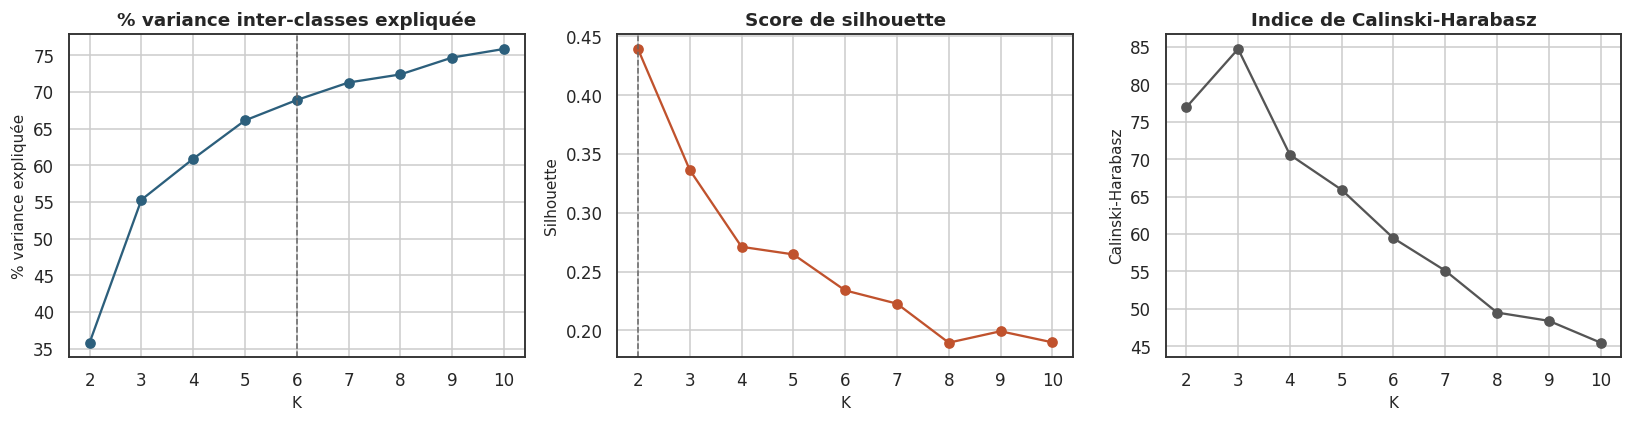

In [24]:
# ===========================================================================
#  SECTION 3 (Cellule 8) — CHOIX DU NOMBRE DE CLUSTERS K
# ===========================================================================

print("=" * 65)
print("  SECTION 3 — COMPARAISON DE PLUSIEURS CRITÈRES POUR CHOISIR K")
print("=" * 65)

K_MIN, K_MAX = 2, 10

inertie_totale = np.sum((X_axes - X_axes.mean(axis=0)) ** 2)

resultats_k = []
for k in range(K_MIN, K_MAX + 1):
    km_essai = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_essai = km_essai.fit_predict(X_axes)
    pct_variance_expliquee = 100 * (1 - km_essai.inertia_ / inertie_totale)
    resultats_k.append({
        "k": k,
        "inertie": km_essai.inertia_,
        "pct_variance_expliquee": pct_variance_expliquee,
        "silhouette": silhouette_score(X_axes, labels_essai),
        "calinski_harabasz": calinski_harabasz_score(X_axes, labels_essai),
    })

comparaison_k = pd.DataFrame(resultats_k)
display(comparaison_k.round(3))

# Coude sur le % de variance expliquée : premier K après lequel le gain marginal
# passe sous 3 points de pourcentage (diminishing returns)
gains_marginaux = comparaison_k["pct_variance_expliquee"].diff().fillna(comparaison_k["pct_variance_expliquee"])
k_coude = int(comparaison_k.loc[gains_marginaux < 3, "k"].iloc[0]) if (gains_marginaux < 3).any() else K_MAX
k_silhouette_max = int(comparaison_k.loc[comparaison_k["silhouette"].idxmax(), "k"])

print(f"\n💡 K suggéré par le coude (variance expliquée, gain marginal < 3 pts) : {k_coude}")
print(f"💡 K suggéré par le maximum de silhouette : {k_silhouette_max}")

fig, axes_plot = plt.subplots(1, 3, figsize=(15, 4))

axes_plot[0].plot(comparaison_k["k"], comparaison_k["pct_variance_expliquee"], marker="o", color=COULEUR_PRINCIPALE)
axes_plot[0].axvline(k_coude, linestyle="--", color="#666666", linewidth=1)
axes_plot[0].set_title("% variance inter-classes expliquée")
axes_plot[0].set_xlabel("K")
axes_plot[0].set_ylabel("% variance expliquée")

axes_plot[1].plot(comparaison_k["k"], comparaison_k["silhouette"], marker="o", color=COULEUR_ACCENT)
axes_plot[1].axvline(k_silhouette_max, linestyle="--", color="#666666", linewidth=1)
axes_plot[1].set_title("Score de silhouette")
axes_plot[1].set_xlabel("K")
axes_plot[1].set_ylabel("Silhouette")

axes_plot[2].plot(comparaison_k["k"], comparaison_k["calinski_harabasz"], marker="o", color="#555555")
axes_plot[2].set_title("Indice de Calinski-Harabasz")
axes_plot[2].set_xlabel("K")
axes_plot[2].set_ylabel("Calinski-Harabasz")

plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_choix_k_criteres.png", dpi=300, bbox_inches="tight")
plt.show()

comparaison_k.to_csv(DOSSIER_TABLES / "G10_choix_k_kmeans.csv", index=False, encoding="utf-8-sig")

# Note : K_RETENU n'est PAS fixé ici. Ce n'est qu'un premier critère parmi
# six calculés au fil des Sections 3-BIS à 3-QUATER (chacune dans sa propre
# cellule numérotée ci-dessous) — la décision finale, qui les pèse tous,
# est prise en Section 3-QUINQUIES.


---
### Section 3-BIS (Cellule 9) — Stabilité des clusters par bootstrap

Un K peut sembler bon sur les données observées tout en étant instable (une infime variation des
données change radicalement la partition — mauvais signe pour la généralisation). On ré-échantillonne
100 fois avec remise et on compare, pour chaque tirage, la partition obtenue sur l'échantillon à
celle obtenue sur les données complètes (ARI = Adjusted Rand Index, 1 = partitions identiques).


  SECTION 3-BIS — STABILITÉ BOOTSTRAP (100 tirages par K)
   K=2 : ARI moyen (stabilité) = 0.775
   K=3 : ARI moyen (stabilité) = 0.972
   K=4 : ARI moyen (stabilité) = 0.749
   K=5 : ARI moyen (stabilité) = 0.814
   K=6 : ARI moyen (stabilité) = 0.694
   K=7 : ARI moyen (stabilité) = 0.645
   K=8 : ARI moyen (stabilité) = 0.564
   K=9 : ARI moyen (stabilité) = 0.571
   K=10 : ARI moyen (stabilité) = 0.521

💡 K le plus stable sous ré-échantillonnage : 3 (ARI=0.972)


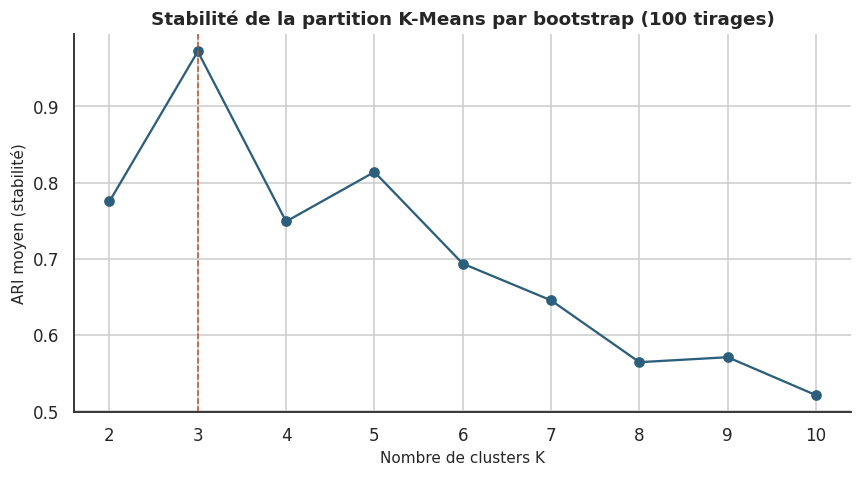

In [25]:
# ===========================================================================
#  SECTION 3-BIS (Cellule 10) — STABILITÉ DES CLUSTERS PAR BOOTSTRAP
#
#  Complète les critères ci-dessus : un K peut sembler bon sur les données
#  observées tout en étant instable (une infime variation des données change
#  radicalement la partition — mauvais signe pour la généralisation). Ici, on
#  ré-échantillonne 100 fois avec remise et on compare, pour chaque tirage, la
#  partition obtenue sur l'échantillon à celle obtenue sur les données
#  complètes (ARI = Adjusted Rand Index, 1 = partitions identiques).
# ===========================================================================

from sklearn.utils import resample

print("=" * 65)
print("  SECTION 3-BIS — STABILITÉ BOOTSTRAP (100 tirages par K)")
print("=" * 65)

N_BOOTSTRAP = 100
ari_bootstrap = {}

for k in range(K_MIN, K_MAX + 1):
    km_reference = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_axes)
    labels_reference = km_reference.labels_

    ari_tirages = []
    for i_tirage in range(N_BOOTSTRAP):
        # random_state=SEED + i_tirage : chaque tirage doit être différent (c'est le principe
        # du bootstrap), mais la SÉQUENCE des 100 tirages doit être reproductible d'une
        # exécution à l'autre du notebook — random_state=None (utilisé dans une version
        # précédente) cassait cette reproductibilité, contrairement à SEED=42 partout ailleurs.
        X_boot, idx_boot = resample(X_axes, np.arange(X_axes.shape[0]), replace=True, random_state=SEED + i_tirage)
        labels_boot = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(X_boot)
        ari_tirages.append(adjusted_rand_score(labels_reference[idx_boot], labels_boot))

    ari_bootstrap[k] = float(np.mean(ari_tirages))
    print(f"   K={k} : ARI moyen (stabilité) = {ari_bootstrap[k]:.3f}")

k_stabilite = max(ari_bootstrap, key=ari_bootstrap.get)
print(f"\n💡 K le plus stable sous ré-échantillonnage : {k_stabilite} (ARI={ari_bootstrap[k_stabilite]:.3f})")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(ari_bootstrap.keys()), list(ari_bootstrap.values()), marker="o", color=COULEUR_PRINCIPALE)
ax.axvline(k_stabilite, linestyle="--", color=COULEUR_ACCENT, linewidth=1)
ax.set_xlabel("Nombre de clusters K")
ax.set_ylabel("ARI moyen (stabilité)")
ax.set_title(f"Stabilité de la partition K-Means par bootstrap ({N_BOOTSTRAP} tirages)")
sns.despine()
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_choix_k_stabilite_bootstrap.png", dpi=300, bbox_inches="tight")
plt.show()


---
### Section 3-TER (Cellule 11) — Gap Statistic (Tibshirani, Walther & Hastie, 2001)

Compare l'inertie intra-cluster réelle à celle obtenue sur des données de référence tirées
uniformément (sans aucune structure) : plus le "gap" est grand, plus le clustering à ce K capture
une vraie structure et pas un artefact du hasard. Règle de décision de Tibshirani et al. (pas une
simple lecture de courbe) : on retient le plus petit K tel que
Gap(K) ≥ Gap(K+1) − erreur-type(K+1) — le premier K "suffisant".


  SECTION 3-TER — GAP STATISTIC
   K=2 : gap=0.7410  (erreur-type=0.0359)
   K=3 : gap=0.9287  (erreur-type=0.0392)
   K=4 : gap=0.9415  (erreur-type=0.0435)
   K=5 : gap=0.9840  (erreur-type=0.0266)
   K=6 : gap=0.9830  (erreur-type=0.0321)
   K=7 : gap=1.0155  (erreur-type=0.0454)
   K=8 : gap=0.9814  (erreur-type=0.0343)
   K=9 : gap=1.0247  (erreur-type=0.0388)
   K=10 : gap=1.0149  (erreur-type=0.0406)

💡 K suggéré par la règle Gap+1 erreur-type (Tibshirani et al.) : 3


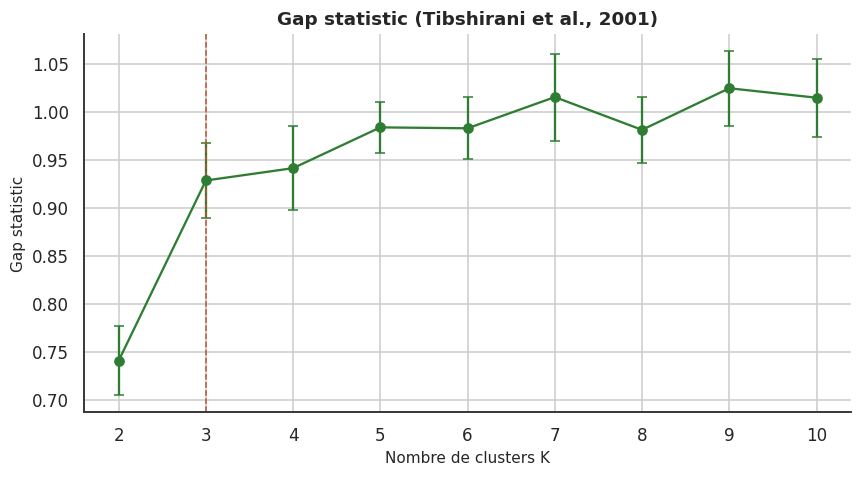

In [26]:
# ===========================================================================
#  SECTION 3-TER (Cellule 12) — GAP STATISTIC (Tibshirani, Walther & Hastie, 2001)
#
#  Compare l'inertie intra-cluster réelle à celle obtenue sur des données de
#  référence tirées uniformément (sans aucune structure) : plus le "gap" est
#  grand, plus le clustering à ce K capture une vraie structure et pas un
#  artefact du hasard. Règle de décision de Tibshirani et al. (pas une simple
#  lecture de courbe) : on retient le plus petit K tel que
#  Gap(K) >= Gap(K+1) − erreur-type(K+1) — le premier K "suffisant".
# ===========================================================================

print("=" * 65)
print("  SECTION 3-TER — GAP STATISTIC")
print("=" * 65)

def calculer_gap_statistic(X, k_min, k_max, n_refs=20, seed=SEED):
    # Générateur local dédié (plutôt que np.random.uniform global) : garantit une
    # séquence de tirages reproductible d'une exécution du notebook à l'autre,
    # cohérent avec SEED=42 utilisé partout ailleurs (une version précédente de
    # cette cellule utilisait l'état aléatoire global, non reproductible).
    rng = np.random.RandomState(seed)
    gaps, erreurs_types = {}, {}
    min_vals, max_vals = X.min(axis=0), X.max(axis=0)
    for k in range(k_min, k_max + 1):
        Wk = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X).inertia_
        logWk_ref = [
            np.log(KMeans(n_clusters=k, random_state=SEED, n_init=10)
                    .fit(rng.uniform(min_vals, max_vals, size=X.shape)).inertia_)
            for _ in range(n_refs)
        ]
        gaps[k] = float(np.mean(logWk_ref) - np.log(Wk))
        erreurs_types[k] = float(np.std(logWk_ref) * np.sqrt(1 + 1 / n_refs))
    return gaps, erreurs_types

gaps, erreurs_types = calculer_gap_statistic(X_axes, K_MIN, K_MAX, n_refs=20)

for k in range(K_MIN, K_MAX + 1):
    print(f"   K={k} : gap={gaps[k]:.4f}  (erreur-type={erreurs_types[k]:.4f})")

# Règle de Tibshirani : premier K tel que Gap(K) >= Gap(K+1) - erreur-type(K+1)
k_gap = K_MAX
for k in range(K_MIN, K_MAX):
    if gaps[k] >= gaps[k + 1] - erreurs_types[k + 1]:
        k_gap = k
        break
print(f"\n💡 K suggéré par la règle Gap+1 erreur-type (Tibshirani et al.) : {k_gap}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(list(gaps.keys()), list(gaps.values()), yerr=list(erreurs_types.values()),
            marker="o", color="#2E7D32", capsize=3)
ax.axvline(k_gap, linestyle="--", color=COULEUR_ACCENT, linewidth=1)
ax.set_xlabel("Nombre de clusters K")
ax.set_ylabel("Gap statistic")
ax.set_title("Gap statistic (Tibshirani et al., 2001)")
sns.despine()
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_choix_k_gap_statistic.png", dpi=300, bbox_inches="tight")
plt.show()


---
### Section 3-QUATER (Cellule 13) — Modèles de mélange gaussien (BIC / AIC)

Angle différent des critères précédents (qui reposent tous sur K-Means / distances) : un GMM
modélise chaque cluster comme une gaussienne et compare les K via des critères pénalisant la
complexité (BIC pénalise plus que AIC). ⚠️ L'AIC est rapporté mais **exclu** de la décision : il
décroît presque monotonement avec K (biais connu vers le sur-ajustement, sans pénalité suffisante
sur le nombre de paramètres). Le BIC, mieux régularisé, est le seul des deux retenu.


  SECTION 3-QUATER — GMM : BIC ET AIC
   K=2 : BIC=2965.2  AIC=2803.4
   K=3 : BIC=2978.1  AIC=2733.9
   K=4 : BIC=3046.1  AIC=2719.6
   K=5 : BIC=3107.8  AIC=2698.9
   K=6 : BIC=3191.1  AIC=2699.8
   K=7 : BIC=3099.2  AIC=2525.6
   K=8 : BIC=3141.2  AIC=2485.2
   K=9 : BIC=3184.3  AIC=2446.0
   K=10 : BIC=3203.4  AIC=2382.7

💡 K minimisant le BIC (retenu) : 2
⚠️ K minimisant l'AIC (écarté, cf. note ci-dessus) : 10


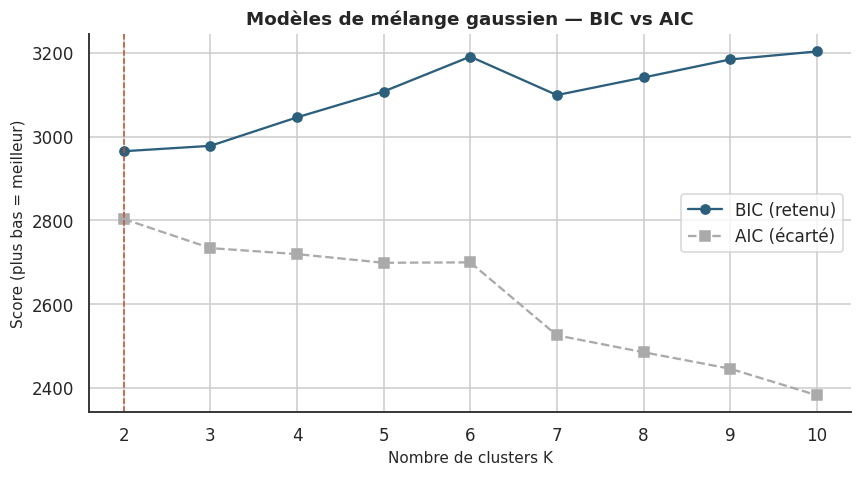

In [27]:
# ===========================================================================
#  SECTION 3-QUATER (Cellule 14) — MODÈLES DE MÉLANGE GAUSSIEN (BIC / AIC)
#
#  Angle différent des critères précédents (qui reposent tous sur K-Means /
#  distances) : un GMM modélise chaque cluster comme une gaussienne et compare
#  les K via des critères pénalisant la complexité (BIC pénalise plus que AIC).
#  ⚠️ L'AIC est rapporté mais EXCLU de la décision : il décroît presque
#  monotonement avec K (biais connu vers le sur-ajustement, sans pénalité
#  suffisante sur le nombre de paramètres) — le minimum atteint en K=10 ici
#  n'est pas un signal de structure, juste l'artefact d'un modèle plus
#  flexible. Le BIC, mieux régularisé, est le seul des deux retenu.
# ===========================================================================

from sklearn.mixture import GaussianMixture

print("=" * 65)
print("  SECTION 3-QUATER — GMM : BIC ET AIC")
print("=" * 65)

bic_scores, aic_scores = {}, {}
for k in range(K_MIN, K_MAX + 1):
    gmm = GaussianMixture(n_components=k, random_state=SEED, n_init=10).fit(X_axes)
    bic_scores[k] = gmm.bic(X_axes)
    aic_scores[k] = gmm.aic(X_axes)
    print(f"   K={k} : BIC={bic_scores[k]:.1f}  AIC={aic_scores[k]:.1f}")

k_bic = min(bic_scores, key=bic_scores.get)
k_aic = min(aic_scores, key=aic_scores.get)
print(f"\n💡 K minimisant le BIC (retenu) : {k_bic}")
print(f"⚠️ K minimisant l'AIC (écarté, cf. note ci-dessus) : {k_aic}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(bic_scores.keys()), list(bic_scores.values()), marker="o", label="BIC (retenu)", color=COULEUR_PRINCIPALE)
ax.plot(list(aic_scores.keys()), list(aic_scores.values()), marker="s", label="AIC (écarté)", color="#AAAAAA", linestyle="--")
ax.axvline(k_bic, linestyle="--", color=COULEUR_ACCENT, linewidth=1)
ax.set_xlabel("Nombre de clusters K")
ax.set_ylabel("Score (plus bas = meilleur)")
ax.set_title("Modèles de mélange gaussien — BIC vs AIC")
ax.legend()
sns.despine()
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_choix_k_gmm_bic_aic.png", dpi=300, bbox_inches="tight")
plt.show()


---
### Section 3-QUINQUIES (Cellule 15) — Synthèse et décision finale sur K

Six critères indépendants ont été calculés (un septième, l'AIC, est écarté pour la raison
méthodologique expliquée en Section 3-QUATER). Le K retenu n'est **pas** celui du critère le plus
"optimisable" isolément, mais celui qui **résiste à plusieurs angles d'analyse différents** —
c'est ce qui définit la robustesse dans le contexte de ce projet : un jury demandera pourquoi ce K
précis, et "cinq méthodes indépendantes convergent" est un argument très différent de "un seuil
choisi sur une courbe".


In [28]:
# ===========================================================================
#  SECTION 3-QUINQUIES (Cellule 16) — SYNTHÈSE ET DÉCISION FINALE SUR K
# ===========================================================================

print("=" * 65)
print("  SECTION 3-QUINQUIES — SYNTHÈSE DE TOUS LES CRITÈRES")
print("=" * 65)

k_calinski = int(comparaison_k.loc[comparaison_k["calinski_harabasz"].idxmax(), "k"])

synthese_k = pd.DataFrame([
    {"critere": "Coude (variance expliquée, seuil 3 pts)", "k_suggere": k_coude,
     "fiabilite": "Heuristique — seuil arbitraire"},
    {"critere": "Silhouette maximale", "k_suggere": k_silhouette_max,
     "fiabilite": "Fiable, mais tend à sous-segmenter"},
    {"critere": "Indice de Calinski-Harabasz (maximal)", "k_suggere": k_calinski,
     "fiabilite": "Fiable — ratio variance inter/intra-cluster"},
    {"critere": "Stabilité bootstrap (ARI, 100 tirages)", "k_suggere": k_stabilite,
     "fiabilite": "Fiable — mesure directement la robustesse"},
    {"critere": "Gap statistic (règle de Tibshirani et al.)", "k_suggere": k_gap,
     "fiabilite": "Fiable — méthode publiée, référence du domaine"},
    {"critere": "GMM — BIC", "k_suggere": k_bic,
     "fiabilite": "Fiable, angle différent (modèle génératif)"},
    {"critere": "GMM — AIC", "k_suggere": k_aic,
     "fiabilite": "❌ Écarté — biais connu vers le sur-ajustement (cf. Section 3-QUATER)"},
])
display(synthese_k)

# ── Vote parmi les critères jugés fiables (AIC exclu) ────────────────────
votes = synthese_k.loc[synthese_k["critere"] != "GMM — AIC", "k_suggere"]
compte_votes = votes.value_counts().sort_index()
print("\n📊 Répartition des votes (6 critères fiables) :")
display(compte_votes.rename("nb_critères"))

# En cas d'égalité de votes, on ne prend PAS arbitrairement le plus petit K :
# on départage par la stabilité bootstrap (Section 3-BIS), le critère qui
# mesure le plus directement la robustesse — l'objectif même de cette section.
k_max_votes = compte_votes.max()
candidats_egalite = compte_votes[compte_votes == k_max_votes].index.tolist()
if len(candidats_egalite) > 1:
    print(f"\n⚖️ Égalité de votes entre K={candidats_egalite} — départage par stabilité bootstrap :")
    for k in candidats_egalite:
        print(f"   K={k} : stabilité bootstrap = {ari_bootstrap[k]:.3f}")
    K_RETENU = max(candidats_egalite, key=lambda k: ari_bootstrap[k])
    print(f"   → K={K_RETENU} retenu (stabilité la plus élevée parmi les ex-æquo)")
else:
    K_RETENU = int(compte_votes.idxmax())

print(f"\n{'=' * 65}")
print(f"  ✅ K RETENU = {K_RETENU}")
print(f"{'=' * 65}")
print(f"""
Justification à reprendre dans le rapport (Section méthodologie) :

K={K_RETENU} est le choix soutenu par le plus grand nombre de critères indépendants parmi les 6
jugés fiables (stabilité bootstrap, gap statistic, Calinski-Harabasz, BIC, silhouette, coude), avec en particulier
une stabilité bootstrap de {ari_bootstrap[K_RETENU]:.3f} — la partition ne change presque pas si
on ré-échantillonne les communes, contrairement à des K plus élevés où la stabilité se dégrade
nettement (K=7 : {ari_bootstrap.get(7, float('nan')):.3f}, K=8 : {ari_bootstrap.get(8, float('nan')):.3f}).

Le critère du coude sur la variance expliquée seul aurait suggéré K={k_coude}, mais ce choix
n'est corroboré par aucun autre critère et présente une stabilité bootstrap nettement plus faible
({ari_bootstrap.get(k_coude, float('nan')):.3f}) — il est écarté au profit du consensus.

👉 Modifiable manuellement si le contenu du profilage (Section 6) s'avère peu interprétable à
   K={K_RETENU} — dans ce cas, documenter explicitement l'écart par rapport au consensus
   statistique et la raison (ex. granularité insuffisante pour la narration du rapport).
""")


  SECTION 3-QUINQUIES — SYNTHÈSE DE TOUS LES CRITÈRES


,critere,k_suggere,fiabilite
0,"Coude (variance expliquée, seuil 3 pts)",6,Heuristique — seuil arbitraire
1,Silhouette maximale,2,"Fiable, mais tend à sous-segmenter"
2,Indice de Calinski-Harabasz (maximal),3,Fiable — ratio variance inter/intra-cluster
3,"Stabilité bootstrap (ARI, 100 tirages)",3,Fiable — mesure directement la robustesse
4,Gap statistic (règle de Tibshirani et al.),3,"Fiable — méthode publiée, référence du domaine"
5,GMM — BIC,2,"Fiable, angle différent (modèle génératif)"
6,GMM — AIC,10,❌ Écarté — biais connu vers le sur-ajustement ...



📊 Répartition des votes (6 critères fiables) :


,nb_critères
k_suggere,
2,2
3,3
6,1



  ✅ K RETENU = 3

Justification à reprendre dans le rapport (Section méthodologie) :

K=3 est le choix soutenu par le plus grand nombre de critères indépendants parmi les 6
jugés fiables (stabilité bootstrap, gap statistic, Calinski-Harabasz, BIC, silhouette, coude), avec en particulier
une stabilité bootstrap de 0.972 — la partition ne change presque pas si
on ré-échantillonne les communes, contrairement à des K plus élevés où la stabilité se dégrade
nettement (K=7 : 0.645, K=8 : 0.564).

Le critère du coude sur la variance expliquée seul aurait suggéré K=6, mais ce choix
n'est corroboré par aucun autre critère et présente une stabilité bootstrap nettement plus faible
(0.694) — il est écarté au profit du consensus.

👉 Modifiable manuellement si le contenu du profilage (Section 6) s'avère peu interprétable à
   K=3 — dans ce cas, documenter explicitement l'écart par rapport au consensus
   statistique et la raison (ex. granularité insuffisante pour la narration du rapport).



---
## Section 4 (Cellule 17) — K-means final


In [29]:
# ===========================================================================
#  SECTION 4 (Cellule 18) — K-MEANS FINAL
# ===========================================================================

print("=" * 65)
print(f"  SECTION 4 — K-MEANS (K = {K_RETENU})")
print("=" * 65)

kmeans_final = KMeans(n_clusters=K_RETENU, random_state=SEED, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_axes)

clusters_kmeans = scores_communes[cols_id + axes_clustering].copy()
clusters_kmeans["cluster_kmeans"] = labels_kmeans

# Palette dimensionnée exactement sur K_RETENU : "Set2"/"tab10" plafonnent à
# 8/10 couleurs qualitatives distinctes ; au-delà, on bascule sur "husl" qui
# génère N teintes également espacées. Garantit une couleur unique par cluster
# sur tous les graphiques ET sur la carte (Section 9), quel que soit K.
from matplotlib.colors import ListedColormap
if K_RETENU <= 8:
    PALETTE_CLUSTERS = sns.color_palette("Set2", K_RETENU)
elif K_RETENU <= 10:
    PALETTE_CLUSTERS = sns.color_palette("tab10", K_RETENU)
else:
    PALETTE_CLUSTERS = sns.color_palette("husl", K_RETENU)
CMAP_CLUSTERS = ListedColormap(PALETTE_CLUSTERS)

taille_clusters = clusters_kmeans["cluster_kmeans"].value_counts().sort_index()
print(f"\n📊 Taille des clusters :")
display(taille_clusters.rename("nb_communes"))

print(f"\n✅ Inertie finale : {kmeans_final.inertia_:.2f}")
print(f"✅ Silhouette finale : {silhouette_score(X_axes, labels_kmeans):.3f}")

display(clusters_kmeans.head(10))


  SECTION 4 — K-MEANS (K = 3)

📊 Taille des clusters :


,nb_communes
cluster_kmeans,
0,74
1,17
2,49



✅ Inertie finale : 1107.20
✅ Silhouette finale : 0.336


,id_commune,nom_commune,arrondissement,adm2_pcode,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,cluster_kmeans
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,10.041542,-3.258678,-4.131774,0.602384,0.226182,-1.316938,1
1,C-002,Delmas,Port-au-Prince,HT0112,9.727956,-1.867859,-4.137420,0.722036,0.688011,-1.632219,1
2,C-003,Cité Soleil,Port-au-Prince,HT0117,4.425251,0.169995,-2.679387,2.486033,2.501844,-1.677778,1
3,C-004,Tabarre,Port-au-Prince,HT0118,6.085279,-1.441390,-3.198570,1.697963,0.437371,-1.398396,1
4,C-005,Carrefour,Port-au-Prince,HT0113,8.132313,-1.670765,-1.522907,0.790299,-0.374735,-1.560038,1
5,C-006,Pétion-Ville,Port-au-Prince,HT0114,9.027931,-2.946373,-1.854825,-1.798893,1.001439,-0.088494,1
6,C-007,Kenscoff,Port-au-Prince,HT0115,0.902069,2.699721,0.995411,-0.677500,1.705557,0.403608,2
7,C-008,Gressier,Port-au-Prince,HT0116,1.767645,1.003326,0.762838,-0.765514,-0.488375,0.377165,2
8,C-009,Léogâne,Léogâne,HT0121,6.188037,-0.763570,1.709820,-0.857216,1.285402,1.366363,1
9,C-010,Petit-Goâve,Léogâne,HT0122,3.681292,-0.223175,1.326483,0.979234,-0.675002,-1.725188,1


---
## Section 5 (Cellule 19) — CHA (Ward) : dendrogramme & validation croisée avec le K-means

La CHA (liaison de Ward) est utilisée ici comme **contrôle de robustesse** de la typologie
K-means : si les deux méthodes convergent vers une partition proche (Adjusted Rand Index élevé),
la typologie est jugée stable et non un artefact de l'algorithme K-means.


  SECTION 5 — CLASSIFICATION HIÉRARCHIQUE ASCENDANTE (WARD)


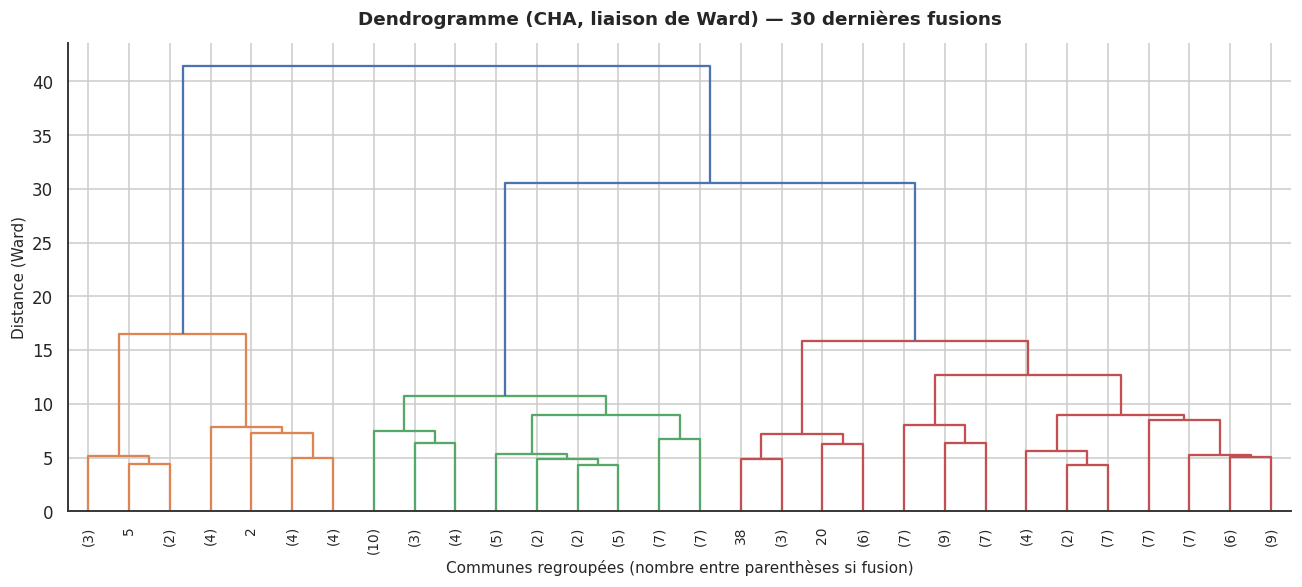

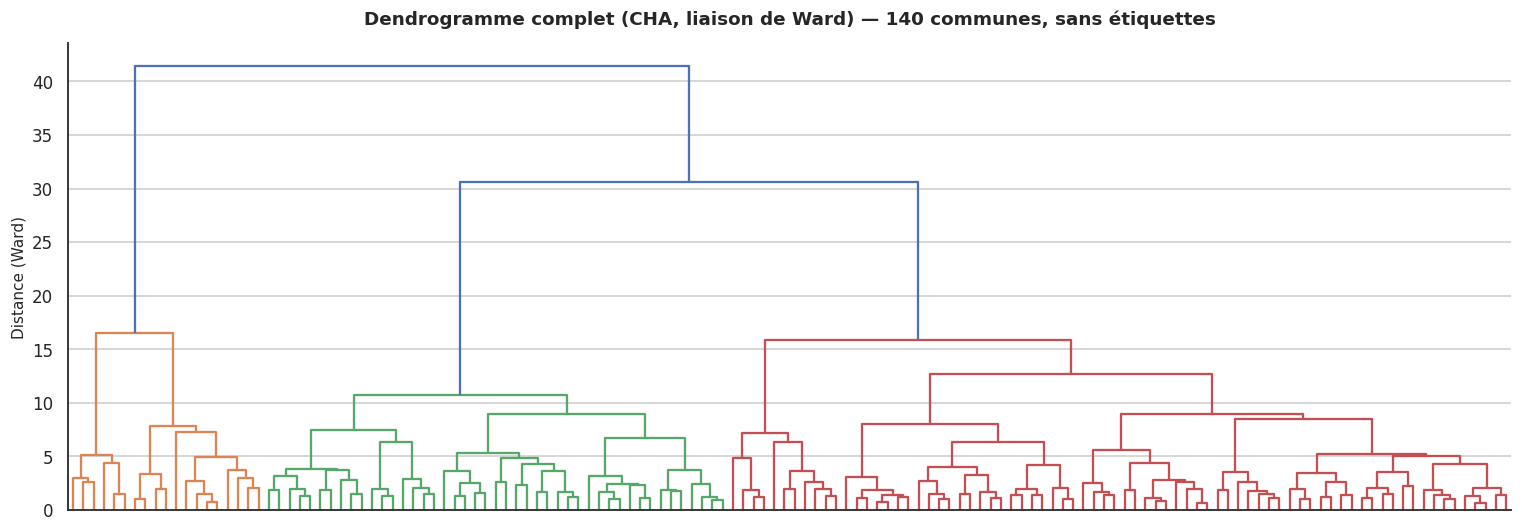


✅ Adjusted Rand Index (K-means vs CHA, K=3) : 0.916
   💡 Proche de 1 : les deux méthodes convergent vers la même typologie (robuste).
      Proche de 0 : les partitions diffèrent — la typologie K-means est moins stable
      et son interprétation doit être plus prudente dans le rapport.

Tableau croisé K-means × CHA :


cluster_cha,0,1,2
cluster_kmeans,,,
0,0,0,74
1,16,0,1
2,3,45,1


In [30]:
# ===========================================================================
#  SECTION 5 (Cellule 20) — CHA (WARD) & VALIDATION CROISÉE
# ===========================================================================

print("=" * 65)
print("  SECTION 5 — CLASSIFICATION HIÉRARCHIQUE ASCENDANTE (WARD)")
print("=" * 65)

linkage_cha = linkage(X_axes, method="ward")

# Seuil de couleur aligné sur K_RETENU : sans ce calcul, scipy choisirait un
# seuil par défaut (0.7 * distance max) qui ne correspond généralement PAS au
# nombre de clusters K_RETENU utilisé partout ailleurs (ARI, carte, profils) —
# un lecteur pourrait alors compter un nombre de couleurs différent du K
# annoncé dans le rapport. Ce seuil garantit exactement K_RETENU couleurs.
if len(linkage_cha) >= K_RETENU > 1:
    seuil_couleur_dendro = linkage_cha[-(K_RETENU - 1), 2]
else:
    seuil_couleur_dendro = None

# Dendrogramme tronqué (30 dernières fusions) : avec 140 communes, un
# dendrogramme complet (140 feuilles nommées) est illisible à l'export — les
# étiquettes se chevauchent complètement. truncate_mode="lastp" affiche les
# fusions les plus hautes du dendrogramme, chaque feuille regroupant "(n)"
# communes le cas échéant — la structure globale reste visible et exploitable
# dans le rapport. Le dendrogramme complet (non tronqué) est sauvegardé à part
# pour consultation détaillée si besoin (fichier _complet, sans étiquettes).
fig, ax = plt.subplots(figsize=(12, 5.5))
dendrogram(
    linkage_cha, ax=ax, color_threshold=seuil_couleur_dendro,
    truncate_mode="lastp", p=30, show_leaf_counts=True,
    leaf_rotation=90, leaf_font_size=9,
)
ax.set_title("Dendrogramme (CHA, liaison de Ward) — 30 dernières fusions", pad=12)
ax.set_xlabel("Communes regroupées (nombre entre parenthèses si fusion)")
ax.set_ylabel("Distance (Ward)")
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_cha_dendrogramme.png", dpi=300, bbox_inches="tight")
plt.show()

# Version complète (140 feuilles, sans étiquettes de noms) conservée à part pour
# consultation détaillée en annexe si besoin — la hauteur de fusion de chaque
# commune individuelle y reste lisible visuellement, sans texte superposé.
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(linkage_cha, ax=ax, color_threshold=seuil_couleur_dendro, no_labels=True)
ax.set_title("Dendrogramme complet (CHA, liaison de Ward) — 140 communes, sans étiquettes", pad=12)
ax.set_ylabel("Distance (Ward)")
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_cha_dendrogramme_complet.png", dpi=300, bbox_inches="tight")
plt.show()

# Coupe du dendrogramme au même K que le K-means, pour comparaison directe
labels_cha = fcluster(linkage_cha, t=K_RETENU, criterion="maxclust") - 1
clusters_kmeans["cluster_cha"] = labels_cha

ari = adjusted_rand_score(labels_kmeans, labels_cha)
print(f"\n✅ Adjusted Rand Index (K-means vs CHA, K={K_RETENU}) : {ari:.3f}")
print("   💡 Proche de 1 : les deux méthodes convergent vers la même typologie (robuste).")
print("      Proche de 0 : les partitions diffèrent — la typologie K-means est moins stable")
print("      et son interprétation doit être plus prudente dans le rapport.")

tableau_croise = pd.crosstab(clusters_kmeans["cluster_kmeans"], clusters_kmeans["cluster_cha"])
print("\nTableau croisé K-means × CHA :")
display(tableau_croise)

comparaison_kmeans_cha = clusters_kmeans[cols_id + ["cluster_kmeans", "cluster_cha"]].copy()
comparaison_kmeans_cha.to_csv(DOSSIER_TABLES / "G10_comparaison_kmeans_cha.csv", index=False, encoding="utf-8-sig")


---
## Section 6 (Cellule 21) — Profil quantitatif des clusters (K-means retenu)


  SECTION 6 — PROFIL QUANTITATIF (AXES ACP) DES CLUSTERS


,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6
cluster_kmeans,,,,,,
0,-1.953,-1.111,-0.079,0.018,-0.028,0.045
1,6.526,-1.202,-0.459,0.161,0.165,-0.022
2,0.685,2.095,0.279,-0.082,-0.016,-0.061


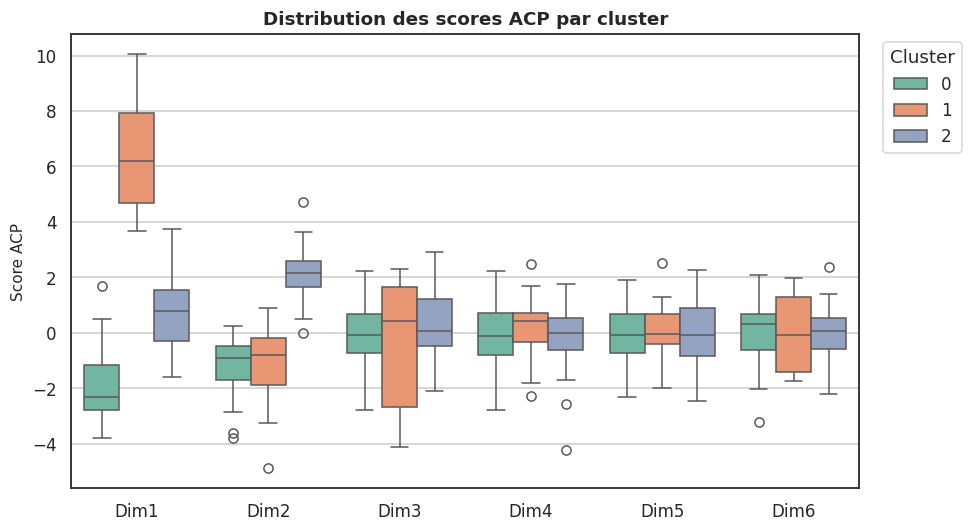

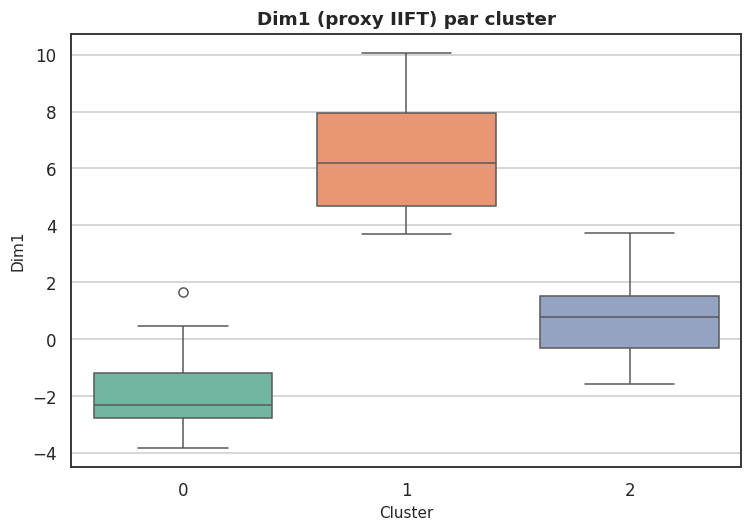

In [31]:
# ===========================================================================
#  SECTION 6 (Cellule 22) — PROFIL QUANTITATIF DES CLUSTERS
# ===========================================================================

print("=" * 65)
print("  SECTION 6 — PROFIL QUANTITATIF (AXES ACP) DES CLUSTERS")
print("=" * 65)

profil_quanti = clusters_kmeans.groupby("cluster_kmeans")[axes_clustering].mean()
display(profil_quanti.round(3))
profil_quanti.reset_index().to_csv(DOSSIER_TABLES / "G10_profil_quantitatif_clusters.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(9, 5))
profil_long = clusters_kmeans.melt(id_vars="cluster_kmeans", value_vars=axes_clustering, var_name="axe", value_name="score")
sns.boxplot(data=profil_long, x="axe", y="score", hue="cluster_kmeans", palette=PALETTE_CLUSTERS, ax=ax)
ax.set_title("Distribution des scores ACP par cluster")
ax.set_xlabel("")
ax.set_ylabel("Score ACP")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_profil_quantitatif_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

if "Dim1" in axes_clustering:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(data=clusters_kmeans, x="cluster_kmeans", y="Dim1", hue="cluster_kmeans",
                palette=PALETTE_CLUSTERS, legend=False, ax=ax)
    ax.set_title("Dim1 (proxy IIFT) par cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Dim1")
    plt.tight_layout()
    fig.savefig(DOSSIER_FIGURES / "G10_dim1_par_cluster.png", dpi=300, bbox_inches="tight")
    plt.show()


---
## Section 7 (Cellule 23) — AFCM sur les variables qualitatives actives

L'AFCM est ajustée sur les variables qualitatives actives (issues de `dico_actif`), indépendamment
des clusters — l'appartenance aux clusters sera projetée en Section 8 comme variable
**illustrative** (elle n'entre pas dans le calcul des axes de l'AFCM elle-même).


In [32]:
# ===========================================================================
#  SECTION 7 (Cellule 24) — AJUSTEMENT DE L'AFCM
# ===========================================================================

print("=" * 65)
print("  SECTION 7 — ANALYSE FACTORIELLE DES CORRESPONDANCES MULTIPLES")
print("=" * 65)

if "type_statistique" not in dico_actif.columns:
    raise ValueError("Le dictionnaire actif doit contenir une colonne 'type_statistique'.")

VARS_QUALI_ACTIVES = dico_actif.loc[dico_actif["type_statistique"] == "Qualitative", "variable"].tolist()
VARS_QUALI_DISPONIBLES = [v for v in VARS_QUALI_ACTIVES if v in matrice_quali_brute.columns]
vars_manquantes = [v for v in VARS_QUALI_ACTIVES if v not in matrice_quali_brute.columns]

if vars_manquantes:
    print(f"⚠️ {len(vars_manquantes)} variable(s) qualitative(s) active(s) absente(s) de la matrice "
          f"qualitative chargée : {vars_manquantes}")
if len(VARS_QUALI_DISPONIBLES) < 2:
    raise ValueError("Au moins deux variables qualitatives actives sont nécessaires pour l'AFCM.")

print(f"✅ {len(VARS_QUALI_DISPONIBLES)} variable(s) qualitative(s) utilisée(s) pour l'AFCM : "
      f"{VARS_QUALI_DISPONIBLES}")

X_afcm = matrice_quali_brute[VARS_QUALI_DISPONIBLES].copy()
for col in X_afcm.columns:
    X_afcm[col] = X_afcm[col].astype("category")

n_manquants = X_afcm.isna().sum().sum()
if n_manquants > 0:
    print(f"⚠️ {n_manquants} valeur(s) manquante(s) — imputées par le mode de chaque colonne "
          f"(garde-fou ; l'imputation de fond doit avoir eu lieu dans le notebook EDA).")
    for col in X_afcm.columns:
        if X_afcm[col].isna().any():
            X_afcm[col] = X_afcm[col].fillna(X_afcm[col].mode(dropna=True).iloc[0])

N_COMPOSANTES_AFCM = min(10, sum(X_afcm[c].nunique() for c in X_afcm.columns) - X_afcm.shape[1])
modele_afcm = prince.MCA(n_components=N_COMPOSANTES_AFCM, n_iter=10, random_state=SEED)
modele_afcm = modele_afcm.fit(X_afcm)

def obtenir_variance_expliquee_afcm(modele):
    """Retourne (eigenvalue, % variance, % variance cumulée), quelle que soit la version de
    `prince` installée (l'API a changé plusieurs fois entre versions)."""
    if hasattr(modele, "eigenvalues_summary"):
        resume = modele.eigenvalues_summary.copy()
        resume.columns = [str(c).lower().replace(" ", "_").replace("%", "pct") for c in resume.columns]
        return resume.reset_index(drop=True)
    valeurs_propres_afcm = np.array(modele.eigenvalues_)
    pct = valeurs_propres_afcm / valeurs_propres_afcm.sum() * 100
    return pd.DataFrame({
        "eigenvalue": valeurs_propres_afcm,
        "pct_of_variance": pct,
        "pct_of_variance_cumulative": np.cumsum(pct),
    })

def obtenir_coordonnees_afcm(modele, X):
    """Retourne les coordonnées factorielles des lignes, quelle que soit la méthode exposée
    par la version de `prince` installée (`row_coordinates` vs `transform`)."""
    if hasattr(modele, "row_coordinates"):
        return modele.row_coordinates(X)
    return modele.transform(X)

variance_afcm = obtenir_variance_expliquee_afcm(modele_afcm)

# Selon la version de `prince`, les colonnes de variance peuvent arriver comme texte
# (ex. "12.3%") au lieu de nombres. On les convertit ici pour éviter les erreurs
# de formatage dans les graphiques et les exports.
# Toute colonne dont le nom contient "eigenvalue" ou "pct_of_variance" est concernée
# (recherche par sous-chaîne plutôt qu'une liste figée de noms exacts : la colonne
# cumulative de prince s'appelle "pct_of_variance_(cumulative)", avec parenthèses,
# et une liste figée de noms l'aurait silencieusement ratée).
colonnes_a_nettoyer = [c for c in variance_afcm.columns if "eigenvalue" in c or "pct_of_variance" in c]
for col in colonnes_a_nettoyer:
    variance_afcm[col] = pd.to_numeric(
        variance_afcm[col].astype(str).str.replace("%", "", regex=False).str.replace(",", ".", regex=False),
        errors="coerce",
    )

if "pct_of_variance" not in variance_afcm.columns or variance_afcm["pct_of_variance"].isna().iloc[:2].any():
    raise ValueError(
        "Impossible de lire la variance expliquee de l'AFCM. Verifiez la sortie de prince.eigenvalues_summary."
    )

variance_afcm.index = [f"Axe {i+1}" for i in range(len(variance_afcm))]

# ── Correction de Benzécri (pourcentages plus lisibles pour le rapport) ────
# Les % bruts d'une AFCM sous-estiment mécaniquement l'inertie "utile" : c'est
# un artefact du codage disjonctif complet (chaque modalité devient une colonne
# binaire), pas un défaut de vos données. La correction de Benzécri (1979) ne
# recalcule PAS la géométrie du nuage — les coordonnées factorielles et donc
# tous les graphiques restent identiques — elle ne change que la lecture du %
# de variance par axe, en ne gardant que l'inertie au-dessus du seuil 1/J
# (J = nombre de variables qualitatives actives), seule part jugée informative.
J = len(VARS_QUALI_DISPONIBLES)
seuil_benzecri = 1 / J

valeurs_propres_brutes = variance_afcm["eigenvalue"].to_numpy()
eligibles = valeurs_propres_brutes > seuil_benzecri
valeurs_propres_corrigees = np.where(
    eligibles, ((J / (J - 1)) * (valeurs_propres_brutes - seuil_benzecri)) ** 2, 0.0,
)
somme_corrigee = valeurs_propres_corrigees.sum()

variance_afcm["eigenvalue_benzecri"] = valeurs_propres_corrigees
variance_afcm["pct_of_variance_benzecri"] = (
    valeurs_propres_corrigees / somme_corrigee * 100 if somme_corrigee > 0 else 0.0
)
variance_afcm["pct_of_variance_cumulative_benzecri"] = variance_afcm["pct_of_variance_benzecri"].cumsum()

print(f"📐 Correction de Benzécri (seuil = 1/J = 1/{J} = {seuil_benzecri:.3f}) — "
      f"{int(eligibles.sum())}/{len(variance_afcm)} axe(s) au-dessus du seuil :")
print(f"   Axe 1 : {variance_afcm['pct_of_variance'].iloc[0]:.1f}% (brut) → "
      f"{variance_afcm['pct_of_variance_benzecri'].iloc[0]:.1f}% (corrigé)")
print(f"   Axe 2 : {variance_afcm['pct_of_variance'].iloc[1]:.1f}% (brut) → "
      f"{variance_afcm['pct_of_variance_benzecri'].iloc[1]:.1f}% (corrigé)")
col_cumul_brut = next((c for c in variance_afcm.columns if "cumulative" in c and "benzecri" not in c), None)
if col_cumul_brut:
    print(f"   Cumulé 2 axes : {variance_afcm[col_cumul_brut].iloc[1]:.1f}% (brut) → "
          f"{variance_afcm['pct_of_variance_cumulative_benzecri'].iloc[1]:.1f}% (corrigé)")

display(variance_afcm.round(2))
variance_afcm.reset_index().rename(columns={"index": "axe"}).to_csv(
    DOSSIER_TABLES / "G10_afcm_valeurs_propres.csv", index=False, encoding="utf-8-sig"
)

coordonnees_afcm = obtenir_coordonnees_afcm(modele_afcm, X_afcm)
coordonnees_afcm.columns = [f"AFCM_Dim{i+1}" for i in range(coordonnees_afcm.shape[1])]
coordonnees_afcm.index = matrice_quali_brute.index

print(f"\n✅ AFCM ajustée sur {N_COMPOSANTES_AFCM} axes (random_state={SEED})")


  SECTION 7 — ANALYSE FACTORIELLE DES CORRESPONDANCES MULTIPLES
✅ 11 variable(s) qualitative(s) utilisée(s) pour l'AFCM : ['strate', 'acces_routier', 'classe_urbanisation', 'classe_densite_demographique', 'classe_densite_bancaire', 'classe_diversite_services', 'classe_privation_spatiale', 'departement', 'classe_taille_population', 'profil_services_financiers', 'classe_taille_menage']
📐 Correction de Benzécri (seuil = 1/J = 1/11 = 0.091) — 10/10 axe(s) au-dessus du seuil :
   Axe 1 : 12.3% (brut) → 66.3% (corrigé)
   Axe 2 : 6.8% (brut) → 10.9% (corrigé)
   Cumulé 2 axes : 19.1% (brut) → 77.2% (corrigé)


,eigenvalue,pct_of_variance,pct_of_variance_(cumulative),eigenvalue_benzecri,pct_of_variance_benzecri,pct_of_variance_cumulative_benzecri
Axe 1,0.37,12.33,12.33,0.09,66.31,66.31
Axe 2,0.20,6.79,19.12,0.02,10.89,77.20
Axe 3,0.18,6.01,25.13,0.01,6.76,83.96
Axe 4,0.17,5.78,30.91,0.01,5.74,89.69
Axe 5,0.16,5.30,36.21,0.01,3.95,93.64
Axe 6,0.14,4.64,40.85,0.00,1.97,95.61
Axe 7,0.14,4.55,45.40,0.00,1.73,97.34
Axe 8,0.13,4.32,49.71,0.00,1.30,98.64
Axe 9,0.12,4.05,53.76,0.00,0.82,99.46
Axe 10,0.12,3.88,57.65,0.00,0.54,100.00



✅ AFCM ajustée sur 10 axes (random_state=42)


---
## Section 7-BIS (Cellule 25) — Robustesse de l'AFCM

Trois vérifications, dans le même esprit que la Section 3 pour le choix de K — la question n'est
pas "l'AFCM tourne-t-elle sans erreur" mais "les résultats se maintiennent-ils sous des
perturbations raisonnables des données, et racontent-ils une histoire cohérente avec le reste de
l'analyse" :

1. **Nombre d'axes réellement interprétables** — la Section 7 en ajuste 10 par défaut, mais tous
   ne sont pas informatifs ; on applique un seuil sur la variance cumulée corrigée (Benzécri).
2. **Stabilité bootstrap des coordonnées factorielles** — les communes ré-échantillonnées
   produisent-elles à peu près le même plan factoriel, ou l'AFCM est-elle sensible au bruit
   d'échantillonnage ?
3. **Cohérence avec le clustering K-Means** — les clusters obtenus indépendamment (sur les axes
   ACP quantitatifs) se séparent-ils aussi sur le plan AFCM (qualitatif) ? Un fort recoupement
   renforce la confiance dans les deux analyses ; un recoupement faible n'est pas forcément un
   problème, mais doit être expliqué dans le rapport (les deux captent des choses différentes).


In [33]:
# ===========================================================================
#  SECTION 7-BIS (Cellule 26) — ROBUSTESSE DE L'AFCM
# ===========================================================================

print("=" * 65)
print("  SECTION 7-BIS — ROBUSTESSE DE L'AFCM")
print("=" * 65)

# ── 1. Nombre d'axes réellement interprétables (seuil sur variance corrigée) ──
SEUIL_VARIANCE_AFCM = 80.0
col_cumul_benzecri = "pct_of_variance_cumulative_benzecri"
n_axes_interpretables = int(
    np.searchsorted(variance_afcm[col_cumul_benzecri].values, SEUIL_VARIANCE_AFCM) + 1
)
n_axes_interpretables = min(n_axes_interpretables, len(variance_afcm))

print(f"1️⃣ Axes interprétables (seuil {SEUIL_VARIANCE_AFCM}% de variance corrigée cumulée) : "
      f"{n_axes_interpretables} / {len(variance_afcm)}")
print(f"   Variance corrigée couverte : "
      f"{variance_afcm[col_cumul_benzecri].iloc[n_axes_interpretables - 1]:.1f}%")
print(f"   👉 Les axes au-delà de {n_axes_interpretables} peuvent être ignorés dans")
print(f"      l'interprétation du rapport, même s'ils restent dans les exports complets.")

# ── 2. Stabilité bootstrap des coordonnées factorielles (axes 1 à 3) ────────
# La comparaison se fait par corrélation de Pearson en VALEUR ABSOLUE : le signe
# d'un axe factoriel est arbitraire (rien ne garantit qu'un réajustement sur un
# sous-échantillon produise le même axe "dans le même sens") — seule l'intensité
# de la relation compte pour juger de la stabilité, pas son signe.
print(f"\n2️⃣ Stabilité bootstrap des coordonnées factorielles (axes 1 à 3) :")

N_BOOTSTRAP_AFCM = 40  # moins que pour K-Means (Section 3-BIS) : un réajustement MCA coûte plus cher
axes_a_verifier = min(3, coordonnees_afcm.shape[1])
correlations_bootstrap_afcm = {f"AFCM_Dim{i+1}": [] for i in range(axes_a_verifier)}

X_afcm_reset = X_afcm.reset_index(drop=True)
coords_originales = coordonnees_afcm.reset_index(drop=True)

# Générateur local dédié + random_state=SEED+i sur chaque MCA : même correctif de
# reproductibilité que les Sections 3-BIS/3-TER (une version précédente utilisait
# l'état aléatoire global et random_state=None, non reproductibles d'une exécution
# à l'autre du notebook).
rng_afcm = np.random.RandomState(SEED)
for i_tirage in range(N_BOOTSTRAP_AFCM):
    idx_boot = rng_afcm.choice(len(X_afcm_reset), size=len(X_afcm_reset), replace=True)
    X_boot = X_afcm_reset.iloc[idx_boot].reset_index(drop=True)
    try:
        modele_boot = prince.MCA(n_components=axes_a_verifier, n_iter=5, random_state=SEED + i_tirage).fit(X_boot)
        coords_boot = obtenir_coordonnees_afcm(modele_boot, X_boot)
        for i in range(axes_a_verifier):
            corr = np.corrcoef(coords_originales.iloc[idx_boot, i].values, coords_boot.iloc[:, i].values)[0, 1]
            correlations_bootstrap_afcm[f"AFCM_Dim{i+1}"].append(abs(corr))
    except Exception:
        continue  # un tirage dégénéré (modalité absente du sous-échantillon) est ignoré, pas fatal

for axe, valeurs in correlations_bootstrap_afcm.items():
    if valeurs:
        print(f"   {axe} : |corrélation| moyenne sur {len(valeurs)} tirages = {np.mean(valeurs):.3f} "
              f"(min={np.min(valeurs):.3f}, max={np.max(valeurs):.3f})")
    else:
        print(f"   {axe} : aucun tirage exploitable")

stabilite_dim1 = np.mean(correlations_bootstrap_afcm.get("AFCM_Dim1", [np.nan]))
if stabilite_dim1 >= 0.8:
    print(f"\n   → Axe 1 stable (≥0.8) : l'interprétation qui en est faite (Section 8) est fiable.")
elif stabilite_dim1 >= 0.6:
    print(f"\n   → Axe 1 modérément stable : l'interprétation générale tient, mais évitez de sur-")
    print(f"      interpréter des différences fines entre communes proches sur cet axe.")
else:
    print(f"\n   → Axe 1 peu stable : à mentionner comme limite méthodologique dans le rapport.")

# ── 3. Cohérence avec le clustering K-Means (eta² sur les 2 premiers axes) ──
print(f"\n3️⃣ Cohérence avec les clusters K-Means (les 2 analyses se recoupent-elles ?) :")

plan_verif = coordonnees_afcm.reset_index(drop=True).copy()
plan_verif["cluster_kmeans"] = clusters_kmeans["cluster_kmeans"].reset_index(drop=True).values

def eta_carre_afcm(valeurs, groupes):
    moyenne_globale = valeurs.mean()
    sce_totale = ((valeurs - moyenne_globale) ** 2).sum()
    sce_inter = sum(
        len(valeurs[groupes == g]) * (valeurs[groupes == g].mean() - moyenne_globale) ** 2
        for g in pd.unique(groupes)
    )
    return sce_inter / sce_totale if sce_totale > 0 else np.nan

for i in range(min(2, coordonnees_afcm.shape[1])):
    axe = f"AFCM_Dim{i+1}"
    eta2 = eta_carre_afcm(plan_verif[axe], plan_verif["cluster_kmeans"])
    print(f"   eta²({axe}, cluster_kmeans) = {eta2:.3f} "
          f"({eta2*100:.0f}% de la variance de cet axe expliquée par le cluster K-Means)")

print(f"\n   👉 Un eta² élevé confirme que les deux méthodes (K-Means sur ACP, AFCM sur variables")
print(f"      qualitatives) racontent une histoire cohérente. Un eta² faible n'invalide ni l'une")
print(f"      ni l'autre : ça signifie juste qu'elles capturent des dimensions différentes de la")
print(f"      disparité territoriale — à documenter explicitement plutôt qu'à ignorer.")

# Export pour référence dans le rapport
robustesse_afcm_export = pd.DataFrame([
    {"critere": "Axes interprétables (seuil 80% variance corrigée)", "valeur": n_axes_interpretables},
    {"critere": "Stabilité bootstrap AFCM_Dim1 (|corr| moyenne)", "valeur": round(stabilite_dim1, 3)},
    {"critere": "eta²(AFCM_Dim1, cluster_kmeans)",
     "valeur": round(eta_carre_afcm(plan_verif["AFCM_Dim1"], plan_verif["cluster_kmeans"]), 3)},
])
robustesse_afcm_export.to_csv(DOSSIER_TABLES / "G10_afcm_robustesse.csv", index=False, encoding="utf-8-sig")
display(robustesse_afcm_export)


  SECTION 7-BIS — ROBUSTESSE DE L'AFCM
1️⃣ Axes interprétables (seuil 80.0% de variance corrigée cumulée) : 3 / 10
   Variance corrigée couverte : 84.0%
   👉 Les axes au-delà de 3 peuvent être ignorés dans
      l'interprétation du rapport, même s'ils restent dans les exports complets.

2️⃣ Stabilité bootstrap des coordonnées factorielles (axes 1 à 3) :
   AFCM_Dim1 : |corrélation| moyenne sur 40 tirages = 0.990 (min=0.971, max=0.996)
   AFCM_Dim2 : |corrélation| moyenne sur 40 tirages = 0.683 (min=0.065, max=0.971)
   AFCM_Dim3 : |corrélation| moyenne sur 40 tirages = 0.436 (min=0.001, max=0.935)

   → Axe 1 stable (≥0.8) : l'interprétation qui en est faite (Section 8) est fiable.

3️⃣ Cohérence avec les clusters K-Means (les 2 analyses se recoupent-elles ?) :
   eta²(AFCM_Dim1, cluster_kmeans) = 0.656 (66% de la variance de cet axe expliquée par le cluster K-Means)
   eta²(AFCM_Dim2, cluster_kmeans) = 0.292 (29% de la variance de cet axe expliquée par le cluster K-Means)

   👉 Un eta

,critere,valeur
0,Axes interprétables (seuil 80% variance corrigée),3.000
1,Stabilité bootstrap AFCM_Dim1 (|corr| moyenne),0.990
2,"eta²(AFCM_Dim1, cluster_kmeans)",0.656


---
## Section 8 (Cellule 27) — Profilage qualitatif des clusters via l'AFCM

Deux lectures complémentaires : (1) la **projection des clusters** sur le plan factoriel AFCM
(variable illustrative — ne modifie pas les axes), et (2) un **tableau de profil** donnant, pour
chaque cluster, la proportion de chaque modalité qualitative (utile pour rédiger le profil-type
de chaque classe dans le rapport).


  SECTION 8 — CLUSTERS PROJETÉS SUR LE PLAN FACTORIEL AFCM
✅ 140/140 communes alignées sur 'id_commune' pour la projection AFCM


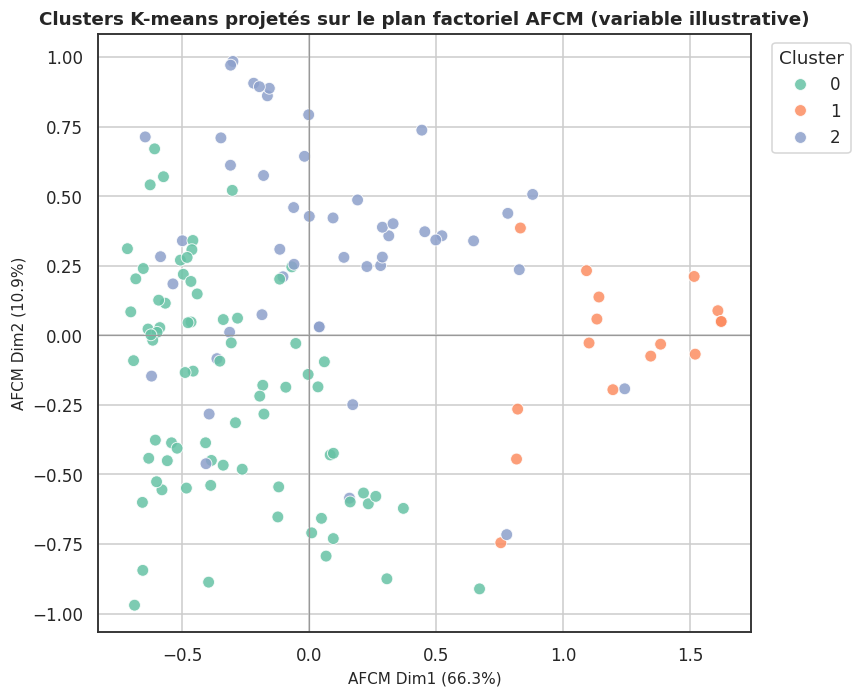


📊 Exemple de profil qualitatif — variable 'strate' :


modalite,Rurale-Connectée (RN),Rurale-Non-connectée (H-Ile),Urbaine-Connectée (RN),Urbaine-Non-connectée (H-Ile),Urbaine-PAP
cluster_kmeans,,,,,
0,8.1,91.9,0.0,0.0,0.0
1,5.9,0.0,41.2,11.8,41.2
2,0.0,0.0,22.4,77.6,0.0


In [34]:
# ===========================================================================
#  SECTION 8 (Cellule 28) — PROFILAGE QUALITATIF DES CLUSTERS (AFCM)
# ===========================================================================

print("=" * 65)
print("  SECTION 8 — CLUSTERS PROJETÉS SUR LE PLAN FACTORIEL AFCM")
print("=" * 65)

# Alignement des index : matrice_quali_brute et clusters_kmeans proviennent de fichiers
# différents — jointure explicite sur un identifiant commun plutôt qu'une simple concaténation
# positionnelle (plus sûr si l'ordre des lignes diffère entre les deux fichiers sources).
id_jointure = next((c for c in ["id_commune", "adm2_pcode", "nom_commune"] if c in matrice_quali_brute.columns and c in clusters_kmeans.columns), None)
if id_jointure is None:
    raise ValueError(
        "Aucun identifiant commun trouvé entre la matrice qualitative et les clusters K-means "
        "pour aligner les communes (attendu : id_commune, adm2_pcode ou nom_commune)."
    )

plan_afcm = pd.concat([matrice_quali_brute[[id_jointure]].reset_index(drop=True), coordonnees_afcm.reset_index(drop=True)], axis=1)
plan_afcm = plan_afcm.merge(clusters_kmeans[[id_jointure, "cluster_kmeans"]], on=id_jointure, how="inner")

print(f"✅ {len(plan_afcm)}/{len(matrice_quali_brute)} communes alignées sur '{id_jointure}' pour la projection AFCM")

if coordonnees_afcm.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(8, 6.5))
    sns.scatterplot(data=plan_afcm, x="AFCM_Dim1", y="AFCM_Dim2", hue="cluster_kmeans",
                     palette=PALETTE_CLUSTERS, s=60, alpha=0.85, ax=ax)
    ax.axhline(0, color="#999999", linewidth=0.8)
    ax.axvline(0, color="#999999", linewidth=0.8)
    ax.set_title("Clusters K-means projetés sur le plan factoriel AFCM (variable illustrative)")
    # Pourcentages corrigés (Benzécri, cf. Section 7) : plus représentatifs de
    # l'inertie réellement portée par chaque axe qu'un % brut d'AFCM.
    ax.set_xlabel(f"AFCM Dim1 ({variance_afcm['pct_of_variance_benzecri'].iloc[0]:.1f}%)")
    ax.set_ylabel(f"AFCM Dim2 ({variance_afcm['pct_of_variance_benzecri'].iloc[1]:.1f}%)")
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    fig.savefig(DOSSIER_FIGURES / "G10_clusters_plan_afcm.png", dpi=300, bbox_inches="tight")
    plt.show()

# ── Tableau de profil qualitatif : proportion de chaque modalité par cluster ──
X_afcm_avec_cluster = X_afcm.reset_index(drop=True).copy()
X_afcm_avec_cluster[id_jointure] = matrice_quali_brute[id_jointure].reset_index(drop=True).values
X_afcm_avec_cluster = X_afcm_avec_cluster.merge(clusters_kmeans[[id_jointure, "cluster_kmeans"]], on=id_jointure, how="inner")

lignes_profil = []
for var in VARS_QUALI_DISPONIBLES:
    proportions = pd.crosstab(X_afcm_avec_cluster["cluster_kmeans"], X_afcm_avec_cluster[var], normalize="index") * 100
    for modalite in proportions.columns:
        for cluster, pct in proportions[modalite].items():
            lignes_profil.append({"variable": var, "modalite": str(modalite), "cluster_kmeans": cluster, "pct_dans_cluster": round(pct, 1)})

profil_quali_clusters = pd.DataFrame(lignes_profil)
profil_quali_clusters.to_csv(DOSSIER_TABLES / "G10_profil_qualitatif_clusters.csv", index=False, encoding="utf-8-sig")

print(f"\n📊 Exemple de profil qualitatif — variable '{VARS_QUALI_DISPONIBLES[0]}' :")
display(profil_quali_clusters[profil_quali_clusters["variable"] == VARS_QUALI_DISPONIBLES[0]]
        .pivot(index="cluster_kmeans", columns="modalite", values="pct_dans_cluster"))


---
### Section 8-BIS (Cellule 29) — Contributions des modalités aux axes AFCM

Complète le profilage de la Section 8 : plutôt que la proportion de chaque modalité *par cluster*,
on regarde ici quelles modalités "portent" le plus chaque axe factoriel AFCM (indépendamment des
clusters), pour pouvoir qualifier chaque pôle de l'axe dans le rapport.


In [35]:
# ===========================================================================
#  SECTION 8-BIS (Cellule 30) — CONTRIBUTIONS DES MODALITÉS AUX AXES AFCM
# ===========================================================================

print("=" * 65)
print("  SECTION 8-BIS — CONTRIBUTIONS DES MODALITÉS AUX AXES AFCM")
print("=" * 65)

# Récupération des coordonnées, cos² et contributions des modalités. L'API exacte de
# `prince` pour ces trois grandeurs a changé plusieurs fois selon les versions (déjà
# rencontré en Section 7 pour les valeurs propres/coordonnées de lignes) :
#   - column_coordinates(X)          : méthode, prend X en argument
#   - column_cosine_similarities(X)  : méthode, prend X — PAS "column_cos2"
#   - column_contributions_          : PROPRIÉTÉ (pas de parenthèses, pas d'argument X),
#                                       et exprimée en FRACTION (somme=1 par axe), pas en %
# Repli automatique sur les anciens noms si une version différente de prince est utilisée.
try:
    coord_col = modele_afcm.column_coordinates(X_afcm)
except AttributeError:
    coord_col = modele_afcm.column_coordinates_

try:
    cos2_col = modele_afcm.column_cosine_similarities(X_afcm)
except AttributeError:
    try:
        cos2_col = modele_afcm.column_cos2(X_afcm)
    except AttributeError:
        cos2_col = modele_afcm.column_cosine_similarities_

try:
    contrib_col = modele_afcm.column_contributions_ * 100  # fraction -> %, cohérent avec l'affichage
except AttributeError:
    contrib_col = modele_afcm.column_contributions(X_afcm)

# Renommage défensif par POSITION (pas par label) : ces trois DataFrames peuvent être
# indexés par des entiers (0,1,2...) ou un nommage différent de "DimN" selon la version
# de prince — un `.sort_values("Dim1")` planterait silencieusement (KeyError) sinon.
# C'est le même principe que obtenir_coordonnees_afcm() en Section 7.
for _df in (coord_col, cos2_col, contrib_col):
    _df.columns = [f"Dim{i+1}" for i in range(_df.shape[1])]

# Sélection des deux premiers axes (ou plus selon n_axes_interpretables)
axes_a_afficher = min(2, coord_col.shape[1])

# Construction d'un tableau récapitulatif pour chaque axe
for axe in range(axes_a_afficher):
    axe_label = f"Dim{axe+1}"
    print(f"\n🔍 Axe {axe+1} — {variance_afcm['pct_of_variance_benzecri'].iloc[axe]:.1f}% de variance corrigée")

    # Trier les modalités par contribution décroissante sur cet axe. On sélectionne
    # UNIQUEMENT la colonne de cet axe AVANT le tri/head/reset_index : contrib_col
    # a une colonne par axe (Dim1..DimN) — sans ce filtre, top_mod garde toutes les
    # colonnes d'axes après reset_index(), et le renommage forcé à 2 colonnes
    # ci-dessous provoque un ValueError (nombre de colonnes incompatible) dès que
    # l'AFCM a plus d'un axe, donc systématiquement.
    top_mod = contrib_col[[axe_label]].sort_values(axe_label, ascending=False).head(10)
    top_mod = top_mod.reset_index()
    top_mod.columns = ["modalite", "contribution_%"]

    # Ajouter les coordonnées et cos² pour lisibilité
    top_mod["coordonnee"] = top_mod["modalite"].map(coord_col[axe_label])
    top_mod["cos2"] = top_mod["modalite"].map(cos2_col[axe_label])

    display(top_mod.round(2))

print("\n💡 Interprétation :")
print("  - Les modalités avec les plus fortes contributions 'portent' l'axe.")
print("  - Le signe de la coordonnée indique le pôle de l'axe auquel elles sont associées.")
print("  - En croisant avec la position des clusters (graphique de la Section 8),")
print("    on peut qualifier chaque cluster par les modalités qui l'attirent.")

  SECTION 8-BIS — CONTRIBUTIONS DES MODALITÉS AUX AXES AFCM

🔍 Axe 1 — 66.3% de variance corrigée


,modalite,contribution_%,coordonnee,cos2
0,profil_services_financiers__Pôle financier com...,14.07,1.91,0.68
1,classe_diversite_services__Élevée,8.77,0.99,0.56
2,strate__Urbaine-PAP,8.05,2.56,0.34
3,departement__Ouest,7.54,1.47,0.36
4,classe_urbanisation__Urbaine,7.23,1.01,0.41
5,classe_densite_bancaire__Élevée,6.98,0.92,0.43
6,classe_taille_population__Grande,6.24,0.87,0.38
7,profil_services_financiers__Aucune institution...,5.24,-0.81,0.32
8,strate__Urbaine-Connectée (RN),4.64,1.21,0.22
9,classe_diversite_services__Moyenne,4.28,-0.54,0.43



🔍 Axe 2 — 10.9% de variance corrigée


,modalite,contribution_%,coordonnee,cos2
0,strate__Urbaine-Non-connectée (H-Ile),8.72,0.83,0.27
1,classe_densite_bancaire__Moyenne,7.11,0.70,0.24
2,profil_services_financiers__Caisse populaire u...,6.61,0.79,0.19
3,departement__Nippes,6.23,-1.33,0.15
4,classe_urbanisation__Urbaine,5.73,0.67,0.18
5,classe_taille_menage__Grande,5.35,0.60,0.18
6,classe_taille_menage__Petite,5.12,-0.58,0.17
7,departement__Nord-Est,4.26,1.01,0.11
8,classe_densite_bancaire__Faible,4.18,-0.53,0.14
9,acces_routier__Éloigné,4.02,0.64,0.12



💡 Interprétation :
  - Les modalités avec les plus fortes contributions 'portent' l'axe.
  - Le signe de la coordonnée indique le pôle de l'axe auquel elles sont associées.
  - En croisant avec la position des clusters (graphique de la Section 8),
    on peut qualifier chaque cluster par les modalités qui l'attirent.


---
### Section 8-TER (Cellule 31) — Niveau IIFT descriptif des clusters

Attribue à chaque cluster une étiquette lisible (ex. "IIFT Élevé") basée sur sa moyenne de Dim1,
pour faciliter la lecture du rapport et de la carte — plus parlant que des numéros de
cluster arbitraires (0, 1, 2...). Cette section est placée AVANT la cartographie (Section 9)
précisément pour que la carte puisse utiliser ces noms dans sa légende, plutôt que de les calculer
après coup sans les exploiter.

**Ceci ne contredit pas la note méthodologique de la Cellule 0** ("l'IIFT ne sert pas au clustering
descriptif") : Dim1 fait partie des axes ACP utilisés pour *former* les clusters depuis le début de
ce notebook (Section 2) — ce qui est exclu, c'est d'utiliser l'IIFT comme *cible* pour un modèle
supervisé (Phase 2.5). Nommer *a posteriori* des clusters déjà formés, pour la lisibilité du
rapport, est une opération purement descriptive.

**Correctif appliqué** : la version précédente attribuait le même nom "IFT_Moyen" à *tous* les
clusters intermédiaires dès que K > 3, aplatissant une typologie à 5-6 classes en 3 niveaux
seulement. Les étiquettes sont maintenant réparties sur une échelle à 10 niveaux (assez pour
K_MAX=10), garantissant un nom distinct par cluster.


In [36]:
# ===========================================================================
#  SECTION 8-TER (Cellule 32) — NIVEAU IIFT DESCRIPTIF DES CLUSTERS
# ===========================================================================

print("=" * 65)
print("  SECTION 8-TER — NIVEAU IIFT DESCRIPTIF DES CLUSTERS (basé sur Dim1)")
print("=" * 65)

# 1. Moyenne de Dim1 pour chaque cluster — variable RENOMMÉE (profil_dim1_par_cluster,
#    pas profil_quanti) : une version précédente réutilisait le nom "profil_quanti",
#    qui écrasait la variable homonyme de la Section 6 (moyennes sur TOUS les axes
#    ACP retenus, pas seulement Dim1). Comme profil_quanti est ré-exportée telle
#    quelle en Section 10, cet écrasement corrompait silencieusement le fichier
#    G10_profil_quantitatif_clusters.csv (il ne contenait plus que Dim1).
profil_dim1_par_cluster = clusters_kmeans.groupby("cluster_kmeans")[["Dim1"]].mean().round(2)

# 2. Trier les clusters par Dim1 croissant (du plus faible au plus fort)
profil_sorted = profil_dim1_par_cluster.sort_values("Dim1")

# 3. Échelle à 10 niveaux (assez pour K_MAX=10) répartie uniformément sur les K
#    clusters via linspace — garantit un nom distinct par cluster quel que soit K,
#    contrairement à la règle précédente (1er/dernier/"Moyen" pour tout le reste),
#    qui donnait le même nom à tous les clusters intermédiaires dès K > 3.
ECHELLE_IIFT = [
    "Très faible", "Faible", "Plutôt faible", "Moyen-faible", "Moyen",
    "Moyen-élevé", "Plutôt élevé", "Élevé", "Très élevé", "Extrême",
]
indices_echelle = np.linspace(0, len(ECHELLE_IIFT) - 1, len(profil_sorted)).round().astype(int)
noms_iift = {
    cluster: f"Classe_IIFT_{ECHELLE_IIFT[i].replace(' ', '_').replace('-', '_')}"
    for cluster, i in zip(profil_sorted.index, indices_echelle)
}

# 4. Ajouter ces noms au dataframe (colonne renommée niveau_iift, plus explicite que nom_iift)
clusters_kmeans["niveau_iift"] = clusters_kmeans["cluster_kmeans"].map(noms_iift)

# 5. Afficher la correspondance
print("\n📊 Correspondance Cluster ↔ Niveau IIFT :")
df_noms_iift = pd.DataFrame([
    {"cluster": k, "Dim1_moyenne": profil_dim1_par_cluster.loc[k, "Dim1"], "niveau_iift": noms_iift[k]}
    for k in sorted(noms_iift.keys())
]).sort_values("Dim1_moyenne")
display(df_noms_iift)

# 6. Exporter
# Export de contrôle à ce stade du pipeline ; G10_clusters_kmeans.csv (Section 10)
# contiendra le même contenu une fois le notebook exécuté jusqu'au bout, puisque
# clusters_kmeans (avec sa colonne niveau_iift) y est réexporté tel quel.
clusters_kmeans.to_csv(
    DOSSIER_TABLES / "G10_clusters_kmeans_avec_iift.csv",
    index=False,
    encoding="utf-8-sig"
)
print("\n✅ Fichier exporté : G10_clusters_kmeans_avec_iift.csv")

  SECTION 8-TER — NIVEAU IIFT DESCRIPTIF DES CLUSTERS (basé sur Dim1)

📊 Correspondance Cluster ↔ Niveau IIFT :


,cluster,Dim1_moyenne,niveau_iift
0,0,-1.95,Classe_IIFT_Très_faible
2,2,0.68,Classe_IIFT_Moyen
1,1,6.53,Classe_IIFT_Extrême



✅ Fichier exporté : G10_clusters_kmeans_avec_iift.csv


---
## Section 9 (Cellule 33) — Cartographie des clusters


  SECTION 9 — CARTE DE LA TYPOLOGIE DES COMMUNES


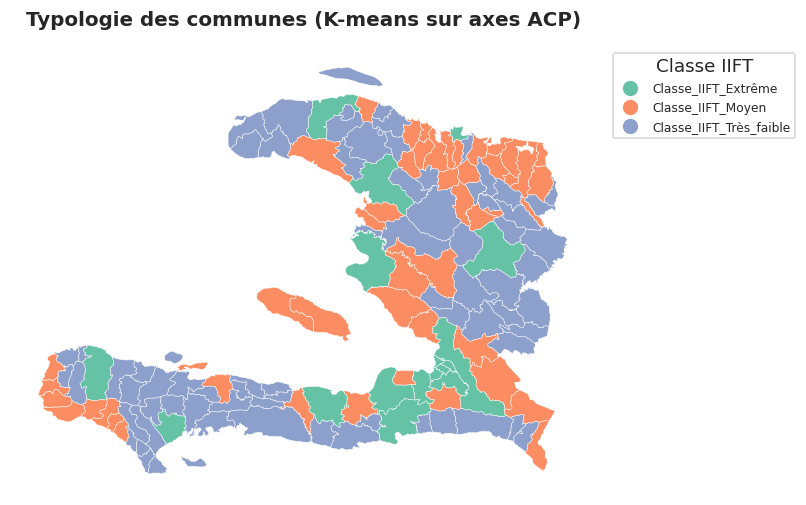

In [37]:
# ===========================================================================
#  SECTION 9 (Cellule 34) — CARTOGRAPHIE DES CLUSTERS
# ===========================================================================

print("=" * 65)
print("  SECTION 9 — CARTE DE LA TYPOLOGIE DES COMMUNES")
print("=" * 65)

with urllib.request.urlopen(CHEMIN_GEOJSON, timeout=30) as reponse:
    geojson_bytes = reponse.read()
with tempfile.NamedTemporaryFile(suffix=".geojson", delete=False) as tmp:
    tmp.write(geojson_bytes)
    chemin_geojson_local = tmp.name

communes_geo = gpd.read_file(chemin_geojson_local).to_crs(epsg=4326)

if "adm2_pcode" in clusters_kmeans.columns:
    fond_carte_clusters = communes_geo.merge(clusters_kmeans, on="adm2_pcode", how="left")
else:
    # Repli : jointure par nom normalisé (même logique que les notebooks EDA/ACP)
    def normaliser(nom):
        nom = str(nom).strip().lower()
        nom = unicodedata.normalize('NFKD', nom).encode('ascii', 'ignore').decode()
        return re.sub(r'[^a-z0-9]', '', nom)
    communes_geo['norm'] = communes_geo['adm2_name'].apply(normaliser)
    clusters_kmeans_tmp = clusters_kmeans.copy()
    clusters_kmeans_tmp['norm'] = clusters_kmeans_tmp['nom_commune'].apply(normaliser)
    fond_carte_clusters = communes_geo.merge(clusters_kmeans_tmp, on='norm', how='left')

fond_carte_clusters['cluster_kmeans'] = fond_carte_clusters['cluster_kmeans'].astype("Int64").astype(str)

# Légende : noms de classe lisibles (Section 8-TER) plutôt que les numéros bruts
# de cluster — colonne déjà présente puisque Section 8-TER s'exécute avant celle-ci.
colonne_legende = "niveau_iift" if "niveau_iift" in fond_carte_clusters.columns else "cluster_kmeans"

fig, ax = plt.subplots(figsize=(7.5, 7.5))
fond_carte_clusters.plot(
    column=colonne_legende, categorical=True, cmap=CMAP_CLUSTERS, linewidth=0.3, edgecolor="white",
    legend=True, ax=ax,
    missing_kwds={"color": "#E8E8E8", "label": "Donnée manquante"},
    legend_kwds={"loc": "upper left", "bbox_to_anchor": (1.02, 1), "fontsize": 8, "title": "Classe IIFT"},
)
ax.set_title("Typologie des communes (K-means sur axes ACP)", fontsize=13, pad=14)
ax.set_axis_off()
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_carte_clusters.png", dpi=300, bbox_inches="tight")
plt.show()


---
### Section 9-BIS (Cellule 35) — Communes les plus représentatives de chaque cluster

Pour chaque cluster, les communes les plus proches du centroïde (dans l'espace des axes ACP
utilisés pour le clustering) — utile pour illustrer le profil-type de chaque classe dans le
rapport par des exemples concrets plutôt que par des moyennes abstraites.


In [38]:
# ===========================================================================
#  SECTION 9-BIS (Cellule 36) — COMMUNES LES PLUS REPRÉSENTATIVES DE CHAQUE CLUSTER
# ===========================================================================

print("=" * 65)
print("  SECTION 9-BIS — COMMUNES REPRÉSENTATIVES (proches des centroïdes)")
print("=" * 65)

# 1. Calcul des centroïdes dans l'espace des axes ACP utilisés pour le clustering
centroides = clusters_kmeans.groupby("cluster_kmeans")[axes_clustering].mean()

# 2. Pour chaque cluster, calculer la distance euclidienne de chaque commune à son centroïde
#    et sélectionner les 5 plus proches (top 5)
top_n = 5
communes_representatives = []

for cluster in sorted(clusters_kmeans["cluster_kmeans"].unique()):
    # Sous-ensemble du cluster
    mask = clusters_kmeans["cluster_kmeans"] == cluster
    sub = clusters_kmeans.loc[mask, axes_clustering].copy()
    sub["id_commune"] = clusters_kmeans.loc[mask, "id_commune"].values
    sub["nom_commune"] = clusters_kmeans.loc[mask, "nom_commune"].values

    # Distance au centroïde
    cent = centroides.loc[cluster].values
    sub["distance"] = sub[axes_clustering].apply(lambda row: np.linalg.norm(row.values - cent), axis=1)

    # Trier et garder les top_n
    top = sub.sort_values("distance").head(top_n)
    top["cluster"] = cluster
    communes_representatives.append(top[["cluster", "id_commune", "nom_commune", "distance"]])

# 3. Assembler et afficher
df_representatives = pd.concat(communes_representatives, ignore_index=True)

print(f"\n📌 Pour chaque cluster, les {top_n} communes les plus proches du centroïde :\n")
display(df_representatives)

# 4. (Optionnel) Exporter ce tableau
df_representatives.to_csv(DOSSIER_TABLES / "G10_communes_representatives_par_cluster.csv", index=False, encoding="utf-8-sig")
print(f"\n✅ Tableau exporté : G10_communes_representatives_par_cluster.csv")

  SECTION 9-BIS — COMMUNES REPRÉSENTATIVES (proches des centroïdes)

📌 Pour chaque cluster, les 5 communes les plus proches du centroïde :



,cluster,id_commune,nom_commune,distance
0,0,C-023,Cayes-Jacmel,0.980099
1,0,C-026,Côtes-de-Fer,1.146861
2,0,C-118,Beaumont,1.225806
3,0,C-025,Bainet,1.236094
4,0,C-128,Bombardopolis,1.254475
5,1,C-120,Port-de-Paix,2.051156
6,1,C-063,Gonaïves,2.280200
7,1,C-090,Les Cayes,2.455354
8,1,C-012,Croix-des-Bouquets,2.554839
9,1,C-005,Carrefour,2.643000



✅ Tableau exporté : G10_communes_representatives_par_cluster.csv


---
## Section 10 (Cellule 37) — Exports des résultats

Les tables sont enregistrées dans `output/tables/clustering_afcm_tables/` et les figures HD (300 dpi) dans
`output/figures/`. Un zip des figures est créé et, sous Colab, toutes les tables (CSV) et le zip de figures sont proposés en téléchargement automatique.


In [39]:
# ===========================================================================
#  SECTION 10 (Cellule 38) — EXPORTS CLUSTERING & AFCM
# ===========================================================================

print("=" * 65)
print("  SECTION 10 — EXPORTS")
print("=" * 65)

dictionnaire_clusters = pd.DataFrame([
    {
        "variable": "cluster_kmeans",
        "type": "Typologie catégorielle (profilage descriptif)",
        "echelle": f"0 à {K_RETENU - 1}",
        "interpretation": "Groupe de communes aux profils territoriaux similaires selon les axes ACP retenus.",
        "methode": f"K-means (K={K_RETENU}, random_state={SEED}) sur {n_axes_retenus} axe(s) ACP (Dim1 à Dim{n_axes_retenus}).",
    },
    {
        "variable": "cluster_cha",
        "type": "Typologie catégorielle (contrôle de robustesse)",
        "echelle": f"0 à {K_RETENU - 1}",
        "interpretation": "Partition alternative issue de la CHA (Ward), comparée au K-means via l'Adjusted Rand Index.",
        "methode": f"CHA (liaison de Ward), coupe à K={K_RETENU} clusters.",
    },
    {
        "variable": "niveau_iift",
        "type": "Étiquette descriptive (lisibilité du rapport uniquement)",
        "echelle": "Classe_IIFT_Très_faible à Classe_IIFT_Extrême (Section 8-TER)",
        "interpretation": "Nom lisible attribué à chaque cluster K-means selon sa moyenne de Dim1 — "
                           "ne remplace pas cluster_kmeans, n'intervient pas dans le clustering lui-même.",
        "methode": "Classement des clusters par Dim1 moyen croissant, réparti sur une échelle à 10 niveaux.",
    },
])

exports = {
    "G10_choix_k_kmeans.csv": comparaison_k,
    "G10_clusters_kmeans.csv": clusters_kmeans,
    "G10_comparaison_kmeans_cha.csv": comparaison_kmeans_cha,
    "G10_profil_quantitatif_clusters.csv": profil_quanti.reset_index(),
    "G10_afcm_valeurs_propres.csv": variance_afcm.reset_index().rename(columns={"index": "axe"}),
    "G10_profil_qualitatif_clusters.csv": profil_quali_clusters,
    "G10_dictionnaire_clusters.csv": dictionnaire_clusters,
    "G10_communes_representatives_par_cluster.csv": df_representatives,
}

for nom_fichier, table in exports.items():
    chemin = DOSSIER_TABLES / nom_fichier
    table.to_csv(chemin, index=False, encoding="utf-8-sig")
    print(f"✅ {nom_fichier} exporté — {table.shape[0]} lignes × {table.shape[1]} colonnes")

print()
print("✅ Exports terminés dans output/tables/clustering_afcm_tables")

# ── Export HD (zip) de toutes les figures générées ────────────────────────
import shutil

fichiers_figures = sorted(DOSSIER_FIGURES.glob("*.png"))
print(f"\n📊 {len(fichiers_figures)} figure(s) HD (300 dpi) trouvée(s) dans '{DOSSIER_FIGURES}/'")

if fichiers_figures:
    chemin_zip_base = "G10_Clustering_AFCM_figures_HD"
    chemin_zip = shutil.make_archive(chemin_zip_base, "zip", DOSSIER_FIGURES)
    taille_mo = os.path.getsize(chemin_zip) / (1024 * 1024)
    print(f"✅ {chemin_zip} créé ({taille_mo:.1f} Mo, {len(fichiers_figures)} image(s))")
else:
    chemin_zip = None
    print("⚠️ Aucune figure trouvée — relancez les sections avec graphiques avant cette cellule.")

if IN_COLAB:
    from google.colab import files
    for nom_fichier in exports:
        files.download(str(DOSSIER_TABLES / nom_fichier))
    if chemin_zip:
        files.download(chemin_zip)
    print("\n✅ Téléchargements Colab lancés (tables CSV + zip de figures)")
else:
    print(f"\nℹ️ Hors Colab : récupérez directement les fichiers dans '{DOSSIER_TABLES}/', "
          f"'{DOSSIER_FIGURES}/'" + (f" (ou le zip '{chemin_zip}')" if chemin_zip else ""))


  SECTION 10 — EXPORTS
✅ G10_choix_k_kmeans.csv exporté — 9 lignes × 5 colonnes
✅ G10_clusters_kmeans.csv exporté — 140 lignes × 13 colonnes
✅ G10_comparaison_kmeans_cha.csv exporté — 140 lignes × 6 colonnes
✅ G10_profil_quantitatif_clusters.csv exporté — 3 lignes × 7 colonnes
✅ G10_afcm_valeurs_propres.csv exporté — 10 lignes × 7 colonnes
✅ G10_profil_qualitatif_clusters.csv exporté — 132 lignes × 4 colonnes
✅ G10_dictionnaire_clusters.csv exporté — 3 lignes × 5 colonnes
✅ G10_communes_representatives_par_cluster.csv exporté — 15 lignes × 4 colonnes

✅ Exports terminés dans output/tables/clustering_afcm_tables

📊 10 figure(s) HD (300 dpi) trouvée(s) dans 'output/figures/'
✅ /content/G10_Clustering_AFCM_figures_HD.zip créé (1.4 Mo, 10 image(s))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Téléchargements Colab lancés (tables CSV + zip de figures)


---
## Section 11 (Cellule 39) — Synthèse méthodologique pour le rapport


In [40]:
# ===========================================================================
#  SECTION 11 (Cellule 40) — SYNTHÈSE POUR LE RAPPORT
# ===========================================================================

resume_methodo = f"""
Synthèse méthodologique — Clustering, AFCM & Profilage des communes

1. Le clustering (K-means) a été réalisé sur {n_axes_retenus} axe(s) ACP retenu(s) (Dim1 à
   Dim{n_axes_retenus}), incluant Dim1 — choix cohérent avec un objectif de profilage descriptif
   et non de feature engineering pour la Phase 2.5 (l'IIFT sert de cible en Phase 2.5, pas de
   feature de clustering ici).
2. Le nombre de clusters K={K_RETENU} a été choisi par un VOTE parmi 6 critères indépendants
   (Section 3 à 3-QUINQUIES) : coude sur la variance expliquée, silhouette, Calinski-Harabasz,
   stabilité bootstrap (ARI moyen sur 100 tirages = {ari_bootstrap[K_RETENU]:.3f}), Gap statistic
   (règle de Tibshirani et al., 2001) et BIC d'un modèle de mélange gaussien — l'AIC a été calculé
   mais écarté (biais connu vers le sur-ajustement). Le K retenu est celui soutenu par le plus
   grand nombre de ces critères, et non le résultat d'une lecture de courbe isolée.
3. Une classification hiérarchique ascendante (liaison de Ward) a permis de valider la stabilité
   de la typologie K-means (Adjusted Rand Index = {ari:.3f}).
4. Une AFCM a été ajustée sur {len(VARS_QUALI_DISPONIBLES)} variable(s) qualitative(s) active(s),
   indépendamment du clustering, avec correction de Benzécri pour une lecture plus fidèle de la
   variance par axe (Section 7). Sa robustesse a été vérifiée sur 3 angles (Section 7-BIS) : nombre
   d'axes réellement interprétables, stabilité bootstrap des coordonnées factorielles, et cohérence
   (eta²) avec la typologie K-means.
5. L'appartenance aux clusters a été projetée comme variable illustrative sur le plan factoriel
   AFCM (Section 8) pour décrire le profil qualitatif de chaque cluster, complétée par les
   modalités qui contribuent le plus à chaque axe AFCM (Section 8-BIS).
6. Un tableau de profil (proportion de chaque modalité qualitative par cluster) et un tableau des
   communes les plus représentatives de chaque cluster (Section 9-BIS, distance au centroïde) ont
   été exportés pour appuyer la rédaction du profil-type de chaque classe dans le rapport.
7. Chaque cluster a reçu une étiquette descriptive lisible (ex. "Classe_IIFT_Moyen_élevé",
   Section 8-TER), dérivée de sa moyenne de Dim1 sur une échelle à 10 niveaux — pour la lisibilité
   du rapport et de la carte (Section 9) uniquement, sans réintroduire l'IIFT comme feature ou
   cible de clustering.
8. Aucune matrice d'apprentissage supervisé n'est créée dans ce notebook ; les clusters restent
   un résultat descriptif, distinct de la variable cible IIFT utilisée en Phase 2.5.
"""

print(resume_methodo)



Synthèse méthodologique — Clustering, AFCM & Profilage des communes

1. Le clustering (K-means) a été réalisé sur 6 axe(s) ACP retenu(s) (Dim1 à
   Dim6), incluant Dim1 — choix cohérent avec un objectif de profilage descriptif
   et non de feature engineering pour la Phase 2.5 (l'IIFT sert de cible en Phase 2.5, pas de
   feature de clustering ici).
2. Le nombre de clusters K=3 a été choisi par un VOTE parmi 6 critères indépendants
   (Section 3 à 3-QUINQUIES) : coude sur la variance expliquée, silhouette, Calinski-Harabasz,
   stabilité bootstrap (ARI moyen sur 100 tirages = 0.972), Gap statistic
   (règle de Tibshirani et al., 2001) et BIC d'un modèle de mélange gaussien — l'AIC a été calculé
   mais écarté (biais connu vers le sur-ajustement). Le K retenu est celui soutenu par le plus
   grand nombre de ces critères, et non le résultat d'une lecture de courbe isolée.
3. Une classification hiérarchique ascendante (liaison de Ward) a permis de valider la stabilité
   de la typologie 